# Stochastic Method: CS-01 TAS

**Purpose**: solve the Tele Assistance System as an open Jackson queueing network via SimPy discrete-event simulation across the full adaptation axis, and cross-check against the analytic closed-form solution.

**Inputs**:
- `data/config/profile/{dflt,opti}.json` (PACS-style Variable dicts; same source as the analytic method).
- `data/config/method/stochastic.json` (SimPy method parameters: seed, replications, horizon / warmup in invocations, ...).
- `data/reference/baseline.json` (R1 / R2 thresholds).

**Outputs**:
- `data/results/stochastic/<adaptation>/<profile>.json` - per-run metrics (nodes with `_std` columns + network aggregate + routing + `lambda_z` + embedded `method_config`).
- `data/results/stochastic/<adaptation>/requirements.json` - R1 / R2 verdicts.
- `data/img/stochastic/<adaptation>/*.{png,svg}` - topology, heatmap, diffmap, CI bars, network bars, delta figures.

**Equivalent CLI**:
```bash
python -m src.methods.stochastic --adaptation baseline
python -m src.methods.stochastic --adaptation s1
python -m src.methods.stochastic --adaptation s2
python -m src.methods.stochastic --adaptation aggregate
```

This notebook is thin: all logic lives in `src.methods.stochastic` and `src.view.qn_diagram`. The cells below orchestrate, display, and save figures.

In [1]:
%matplotlib inline
from pathlib import Path

import pandas as pd

from src.methods.analytic import run as run_analytic
from src.methods.stochastic import run as run_stochastic
from src.view import (
    plot_qn_topology,
    plot_node_heatmap,
    plot_node_diffmap,
    plot_node_ci,
    plot_arch_bars,
    plot_arch_delta,
)

IMG_ROOT = Path("data/img/stochastic")
ADAPTATIONS = ["baseline", "s1", "s2", "aggregate"]

# Human-readable scenario labels for plot titles / legends.
DISPLAY = {
    "baseline": "No Adaptation",
    "s1": "S1: Retry",
    "s2": "S2: Select-Reliable",
    "aggregate": "S1 & S2",
}

## 1. Solve every adaptation (SimPy DES)

`run_stochastic(adp=a, wrt=True)` loads `NetCfg`, pulls the method config (seed / replications / horizon / warmup), runs the DES engine across every replication, writes the JSON envelope, and returns the per-replication-averaged per-node frame + network aggregate + R1 / R2 verdict.

In [2]:
results = {
    a: run_stochastic(adp=a, wrt=True) for a in ADAPTATIONS
}

In [3]:
cfgs = {a: results[a]["config"] for a in ADAPTATIONS}
nodes = {a: results[a]["nodes"] for a in ADAPTATIONS}
nets = {a: results[a]["network"] for a in ADAPTATIONS}
reqs = {a: results[a]["requirements"] for a in ADAPTATIONS}
mc = results["baseline"]["method_config"]

In [4]:
# analytic baseline cached once for the CI overlay reference in section 6
analytic_baseline_nodes = run_analytic(adp="baseline",
                                       wrt=False)["nodes"]

print(f"Solved {len(results)} adaptations via SimPy DES; "
      f"seed={mc['seed']} reps={mc['replications']} "
      f"horizon={mc['horizon_invocations']} inv. "
      f"warmup={mc['warmup_invocations']} inv.")

Solved 4 adaptations via SimPy DES; seed=42 reps=10 horizon=10000 inv. warmup=1000 inv.


## 2. Network-wide summary + verdict

One row per adaptation: mean headline metrics across replications and the R1 / R2 pass flags.

In [5]:
rows = []
for a in ADAPTATIONS:
    n = nets[a].iloc[0]
    r = reqs[a]
    rows.append({
        "adaptation": a,
        "profile": cfgs[a].profile,
        r"$\mathbf{W_{e2e}}$ [ms]": n["W_e2e"] * 1000,
        r"$\mathbf{\varepsilon_{e2e}}$ [%]": n["eps_e2e"] * 100,
        r"$\mathbf{\overline{\rho}_{TAS}}$": n["avg_rho"],
        r"$\mathbf{\rho_{TAS,\,Max}}$": n["max_rho"],
        r"$\mathbf{L_{net}}$": n["L_net"],
        "R1 (≤ 1.0%)": "PASS" if r["R1"]["pass"] else "FAIL",
        "R2 (≤ 26 ms)": "PASS" if r["R2"]["pass"] else "FAIL",
    })
pd.DataFrame(rows).set_index("adaptation").round(4)

,profile,$\mathbf{W_{e2e}}$ [ms],$\mathbf{\varepsilon_{e2e}}$ [%],$\mathbf{\overline{\rho}_{TAS}}$,"$\mathbf{\rho_{TAS,\,Max}}$",$\mathbf{L_{net}}$,R1 (≤ 1.0%),R2 (≤ 26 ms)
adaptation,,,,,,,,
baseline,dflt,25.7992,14.7478,0.2924,0.6487,7.1042,FAIL,PASS
s1,opti,27.4214,0.2156,0.3215,0.7055,8.5644,PASS,FAIL
s2,opti,18.6420,10.3878,0.2575,0.5700,5.2288,FAIL,PASS
aggregate,opti,19.2811,0.0711,0.2796,0.6264,6.0307,PASS,PASS


## 3. Per-node snapshot (baseline, mean across reps)

Mean per-node metrics after the warm-up cut-off. The `_std` companions carry the replication-to-replication spread; the CI overlay in section 6 uses them.

In [6]:
nodes["baseline"][[
    "key", "name", "type", "lambda", "mu", "c", "K",
    "rho", "rho_std", "L", "W",
]].round(4)

,key,name,type,lambda,mu,c,K,rho,rho_std,L,W
0,TAS_{1},TAS composite stage 1 (dispatch),M/M/s/K,322.7990,7.513599e+02,1,16,0.4296,0.0040,0.7595,0.0024
1,TAS_{2},TAS composite stage 2 (medical dispatch),M/M/s/K,242.1746,7.502182e+02,1,16,0.3229,0.0067,0.4803,0.0020
2,TAS_{3},TAS composite stage 3 (alarm dispatch),M/M/s/K,152.6426,7.544478e+02,1,16,0.2024,0.0045,0.2526,0.0017
3,MAS_{1},Medical Analysis Service 1,M/M/s/K,90.2211,1.807156e+02,1,16,0.4994,0.0134,0.9918,0.0110
4,MAS_{2},Medical Analysis Service 2,M/M/s/K,88.6491,5.274530e+02,1,16,0.1681,0.0027,0.2035,0.0023
5,MAS_{3},Medical Analysis Service 3,M/M/s/K,97.3522,1.500741e+02,1,16,0.6487,0.0126,1.8654,0.0191
6,AS_{1},Alarm Service 1,M/M/s/K,56.9234,6.993283e+02,1,16,0.0814,0.0026,0.0886,0.0016
7,AS_{2},Alarm Service 2,M/M/s/K,53.8549,4.157243e+02,1,16,0.1296,0.0033,0.1504,0.0028
8,AS_{3},Alarm Service 3,M/M/s/K,61.2264,1.572434e+03,1,16,0.0390,0.0011,0.0404,0.0007
9,TAS_{4},TAS composite stage 4 (drug dispatch),M/M/s/K,242.0670,7.507560e+02,1,16,0.3225,0.0050,0.4764,0.0020


## 4. Queue-network topology per adaptation

Nodes coloured by rho (cool = low, warm = high), scaled to the frame's max. Same plotter as the analytic notebook so the two methods compare visually.

In [7]:
# remove FAIL node to simplify renders
# FAIL_{1} (the absorbing failure sink) stays in the SOLVE for availability
# (eps_e2e = lambda_FAIL/lambda_z); here we drop it from the per-node figures below so the
# topology + heatmaps render the 13-node service mesh. FAIL_{1} is the last node, so slice it off.
# The section 3 table above keeps it (it runs before this cell).
FAIL_KEY = "FAIL_{1}"
nodes = {a: df[df["key"] != FAIL_KEY].reset_index(
    drop=True) for a, df in nodes.items()}
routs = {a: cfgs[a].routing[:-1, :-1] for a in ADAPTATIONS}

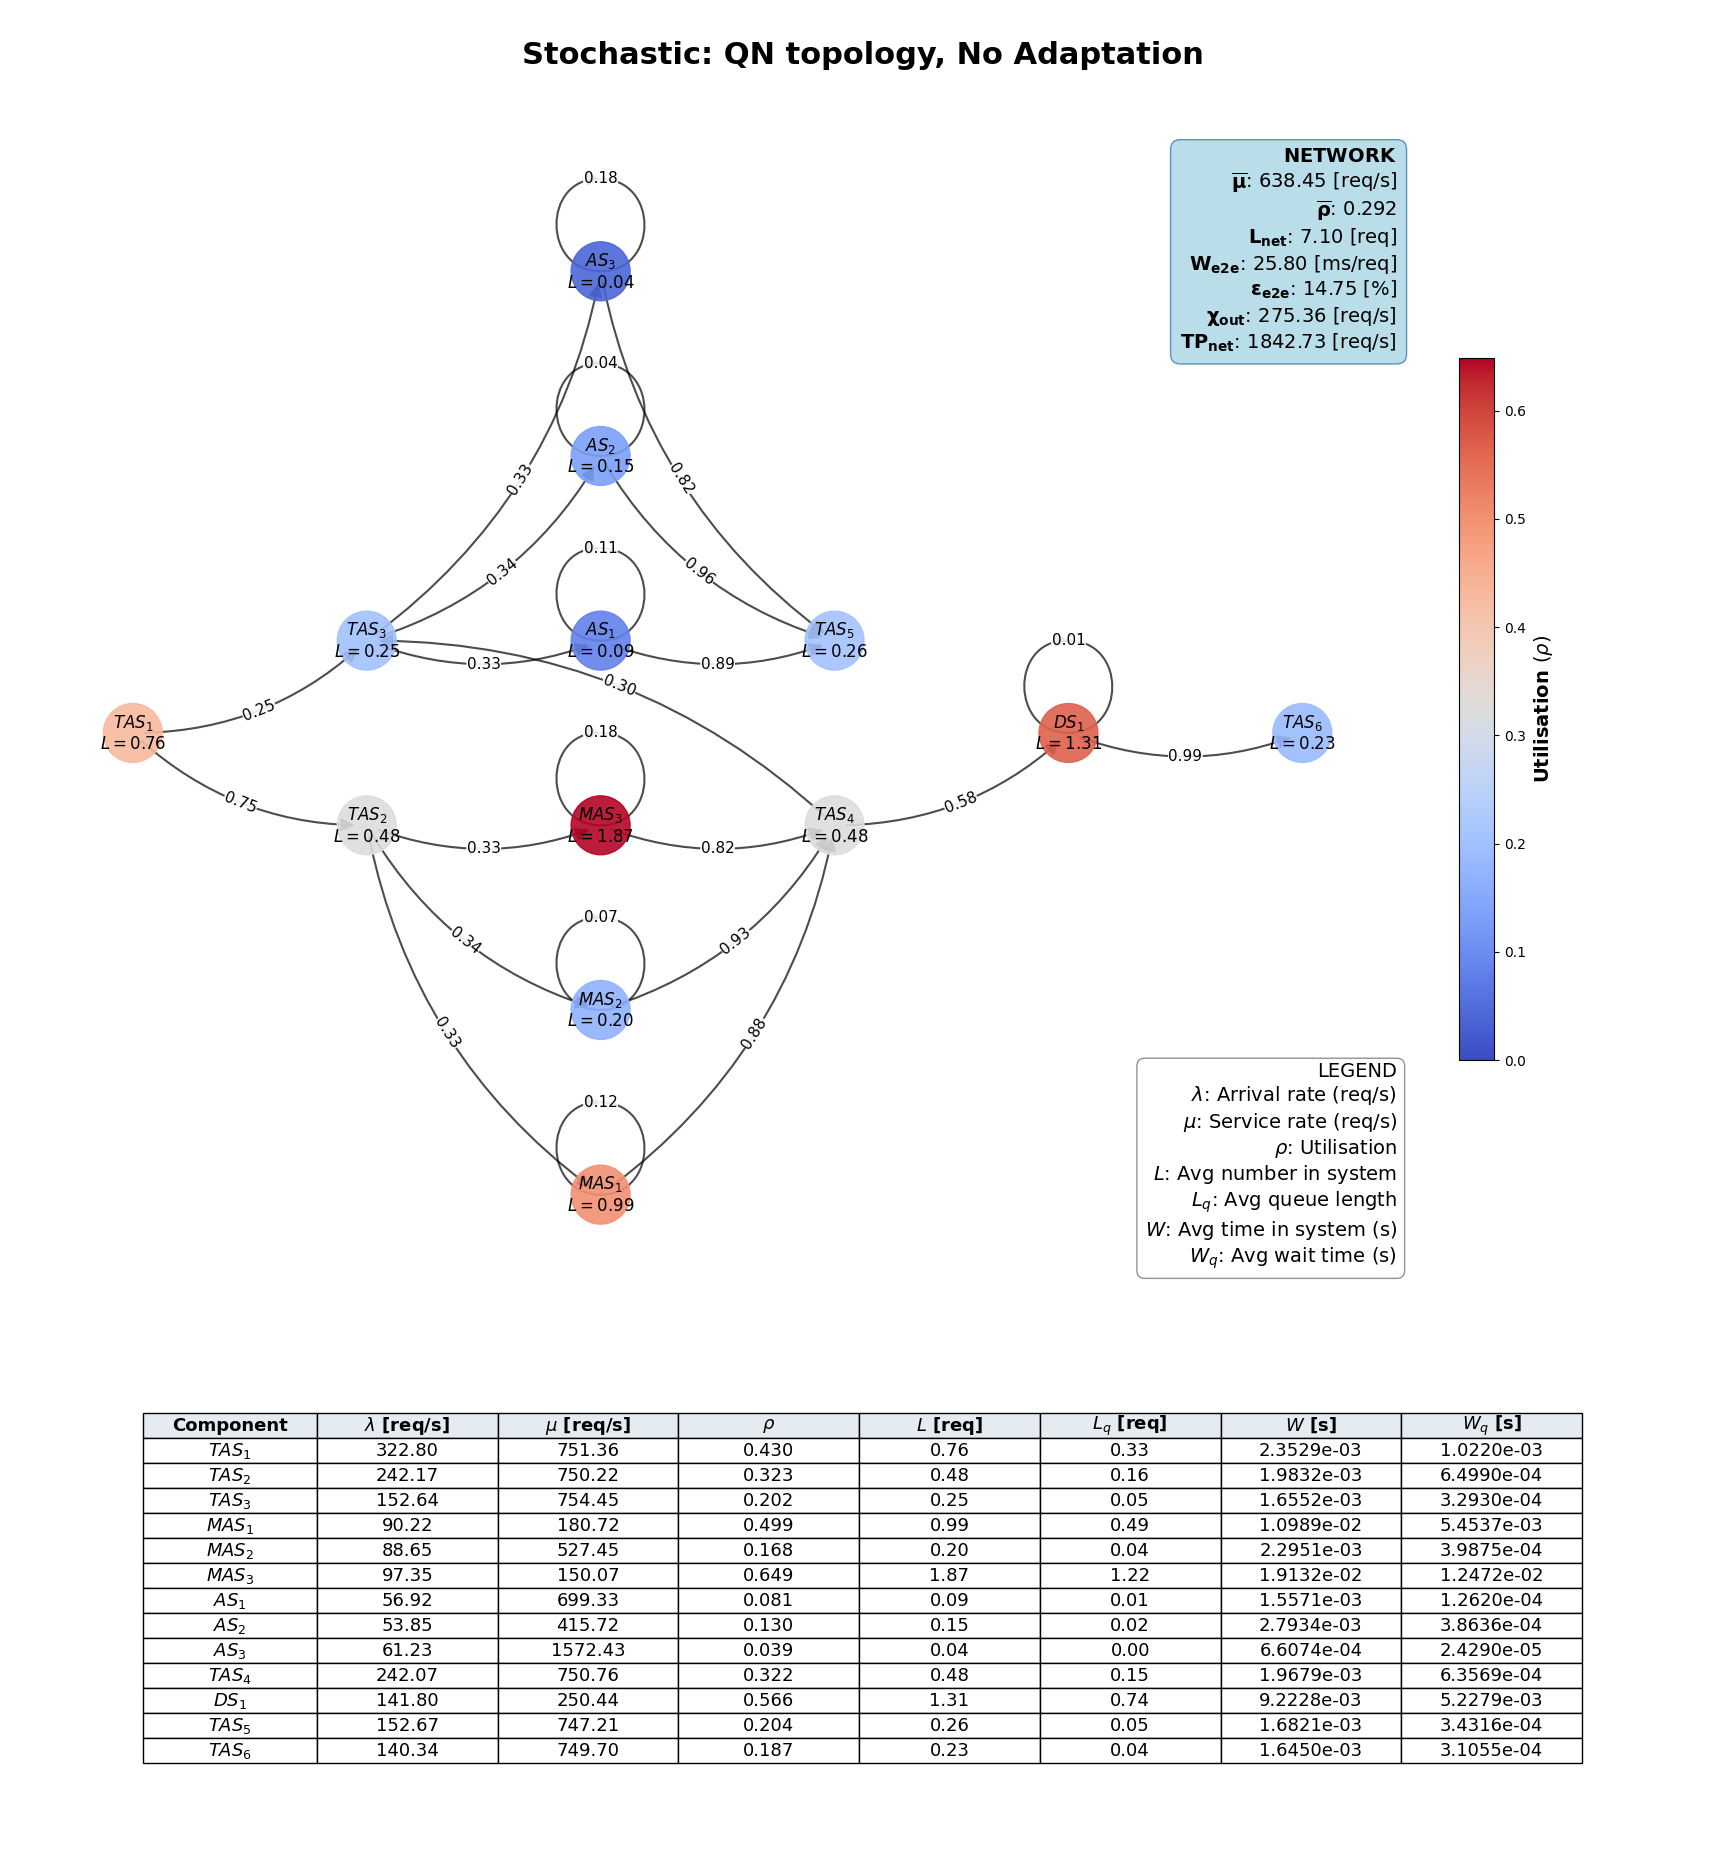

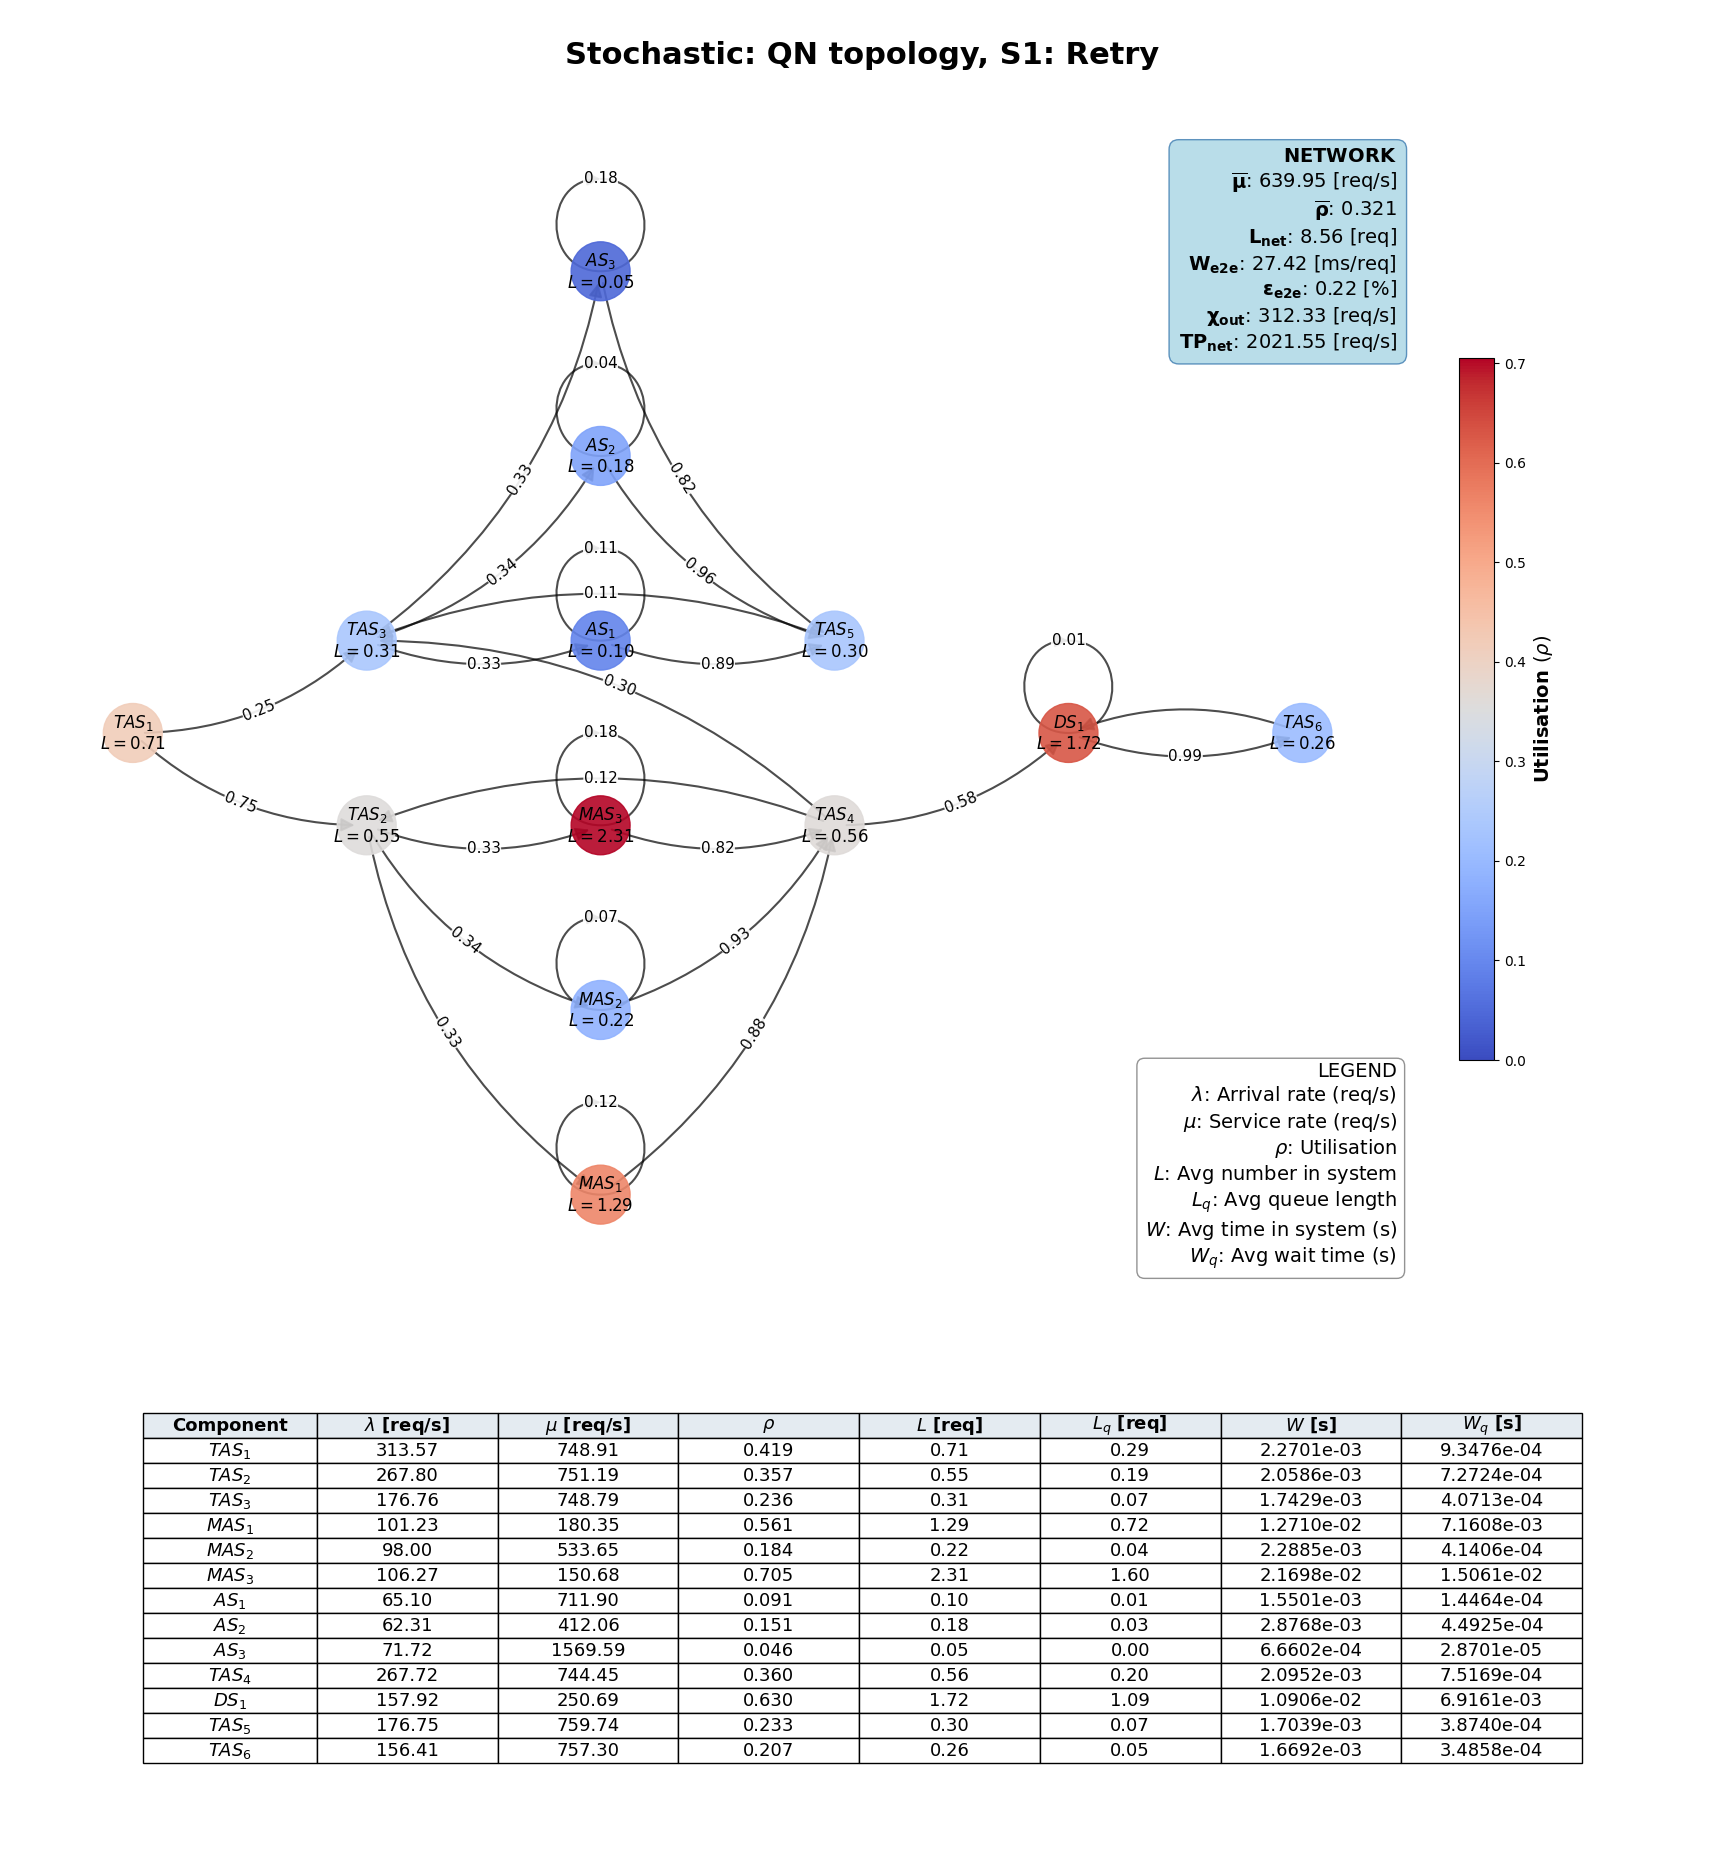

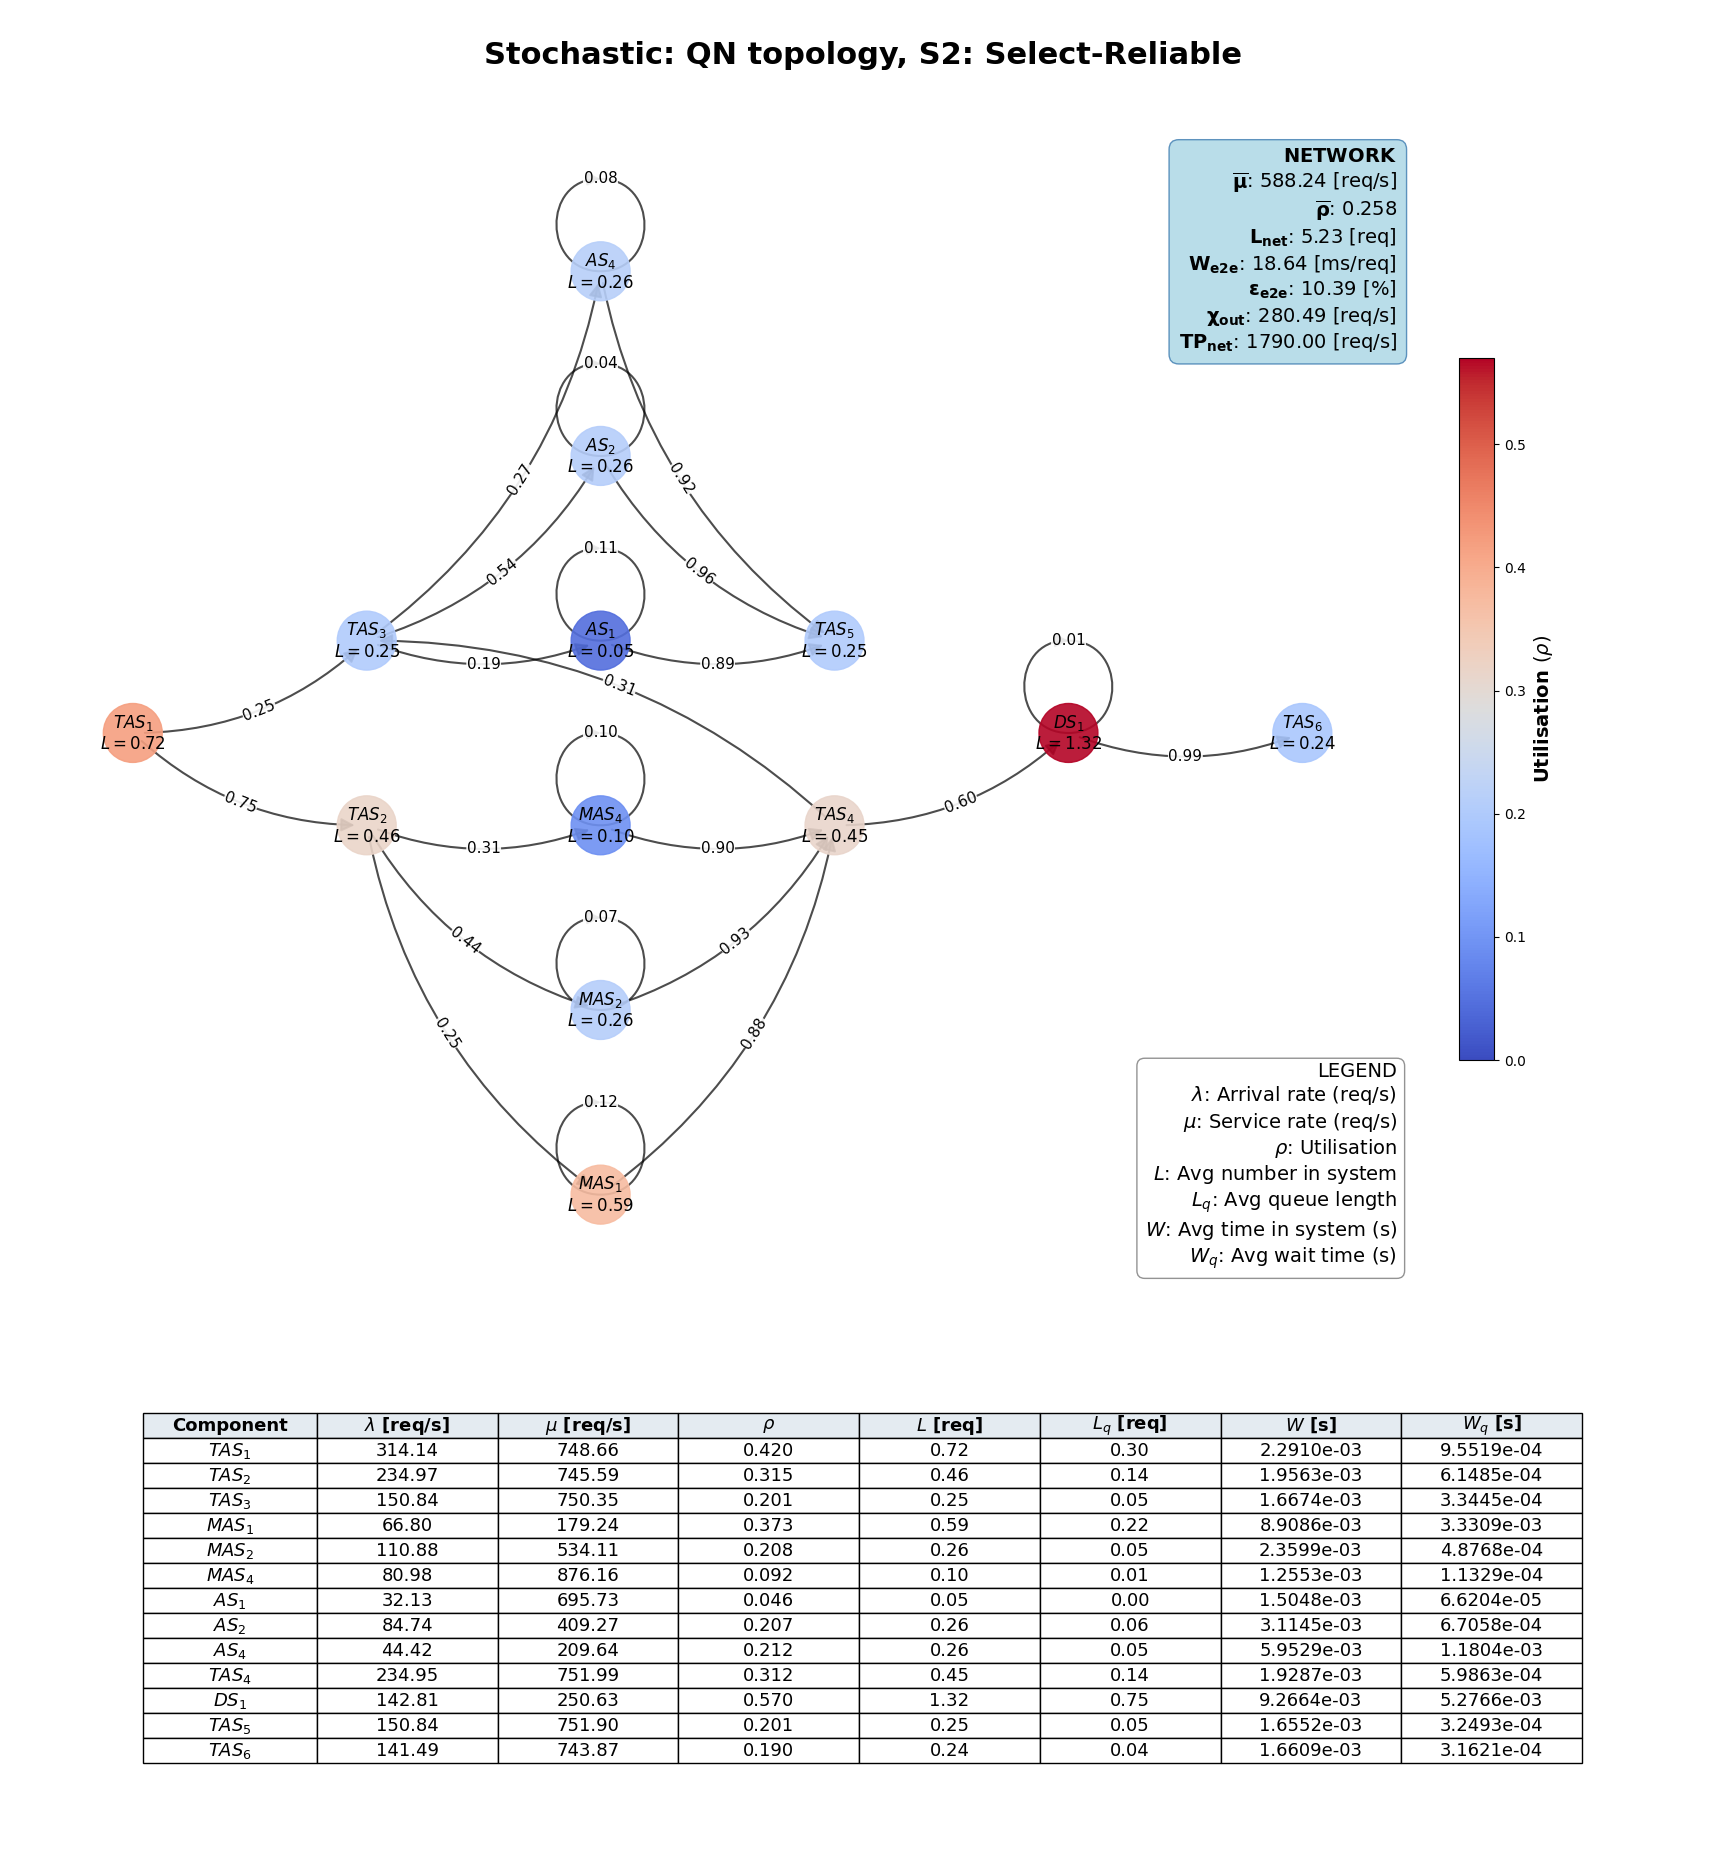

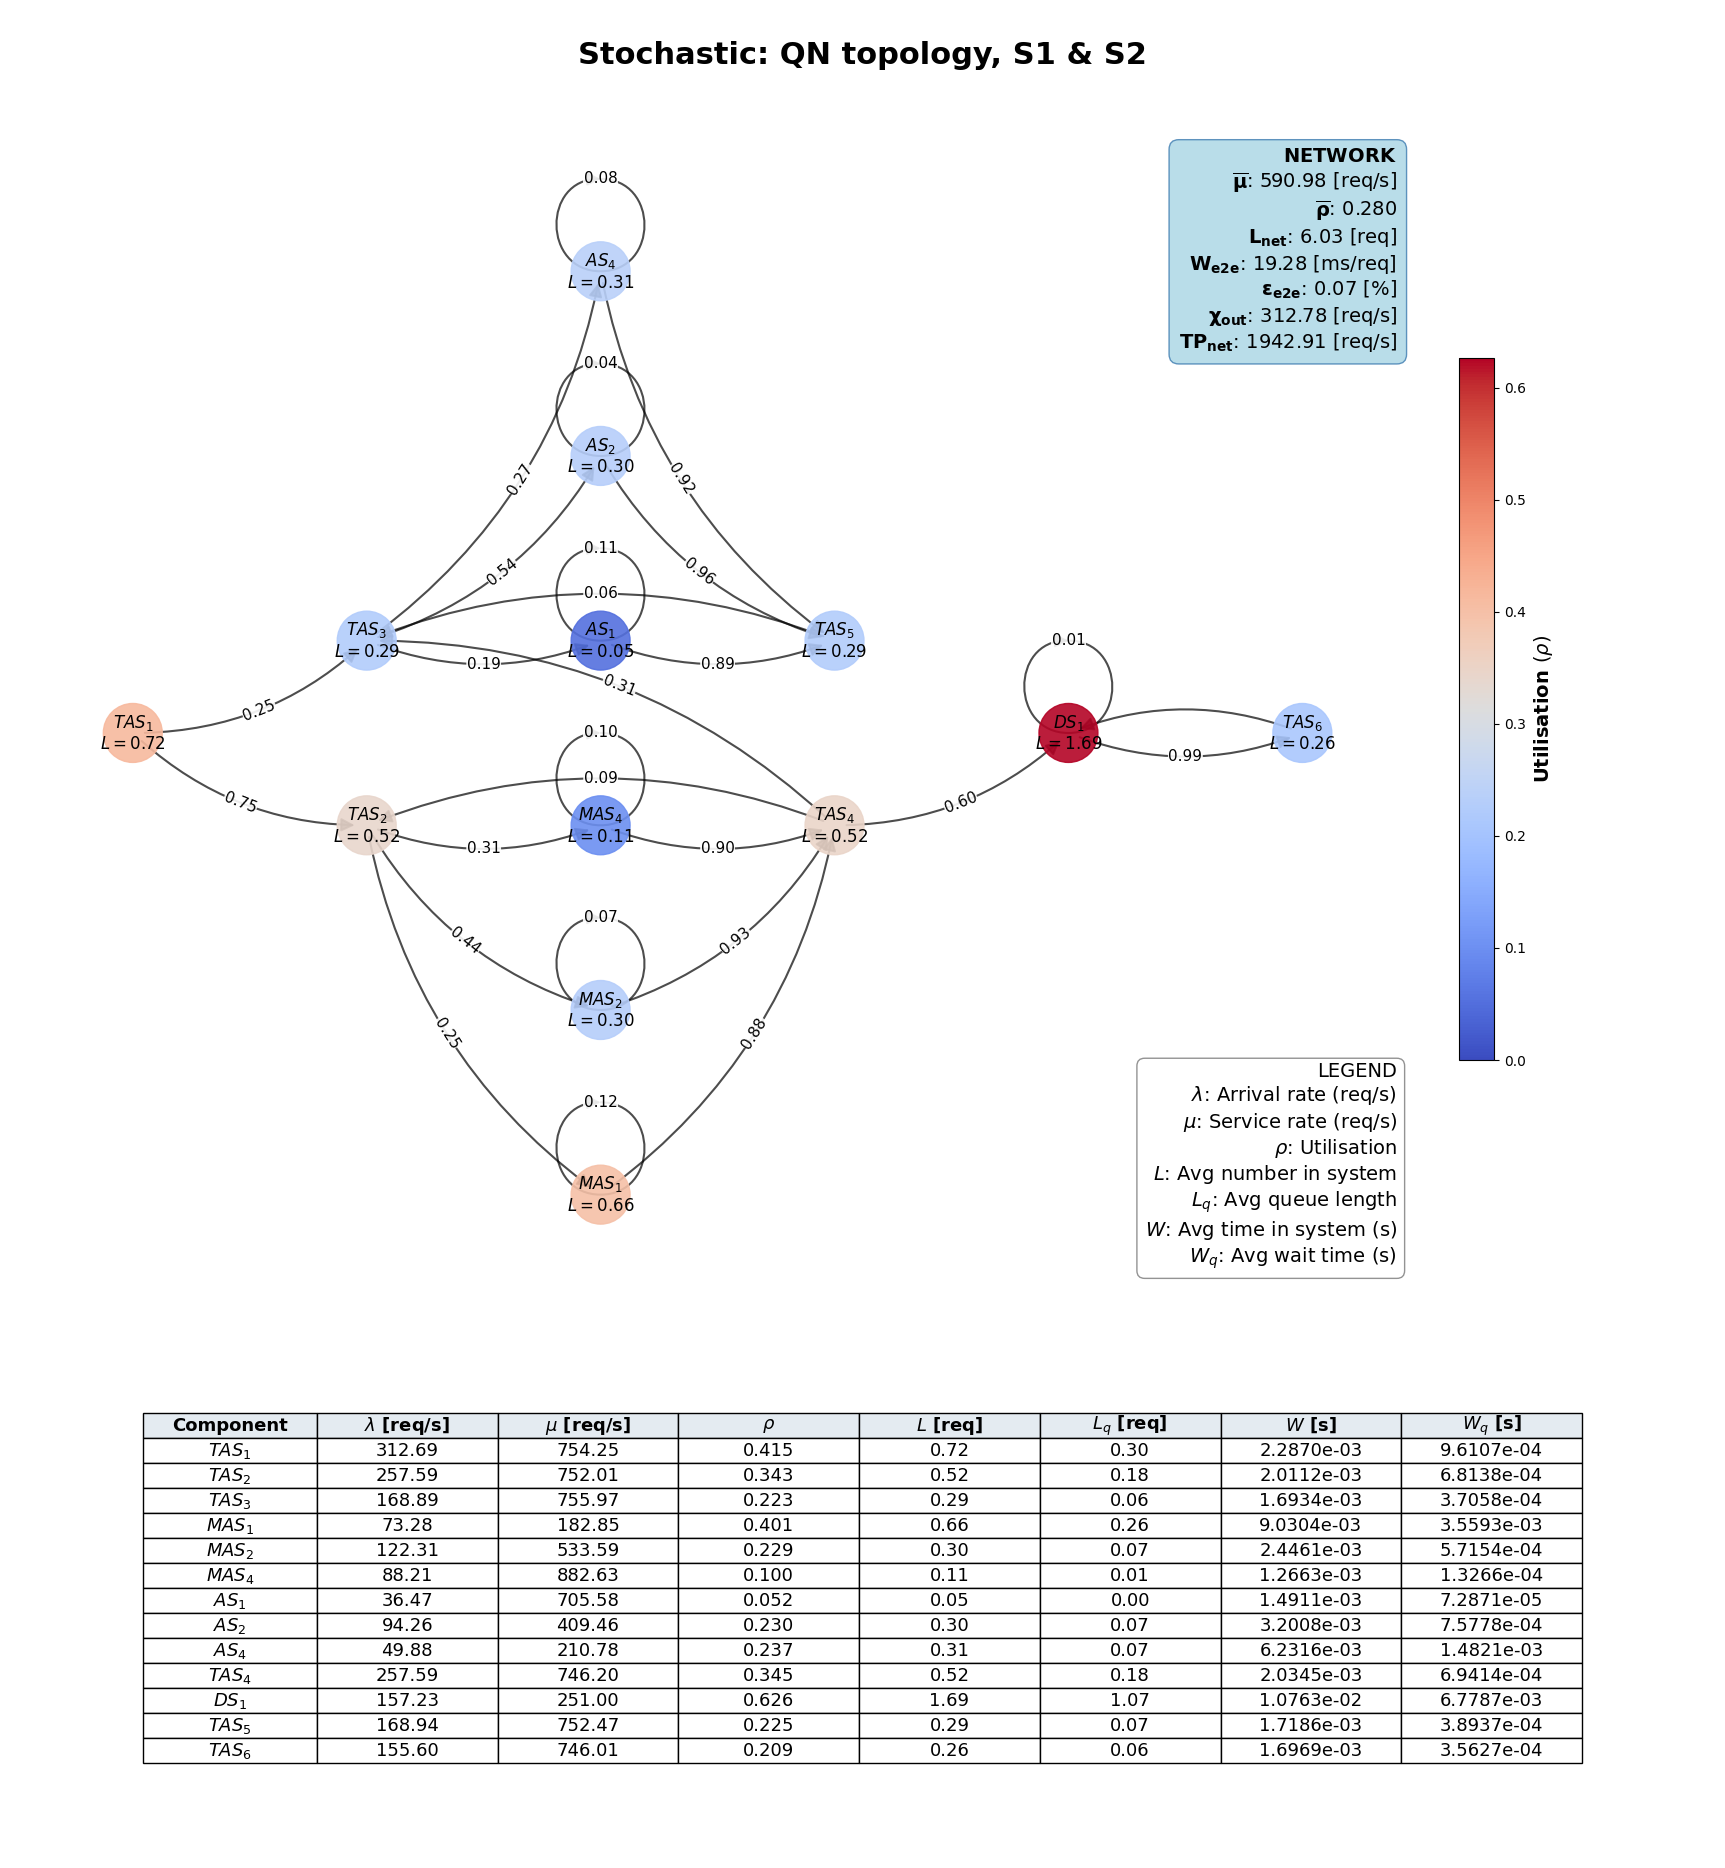

In [8]:
for a in ADAPTATIONS:
    plot_qn_topology(
        routs=routs[a],
        ndss=nodes[a],
        nets=nets[a],
        title=f"Stochastic: QN topology, {DISPLAY[a]}",
        file_path=str(IMG_ROOT / a),
        fname="topology.png")

## 5. Per-node heatmap (before vs after)

Each row = one artifact; each column = one metric. Columns normalised per-metric across both scenarios.

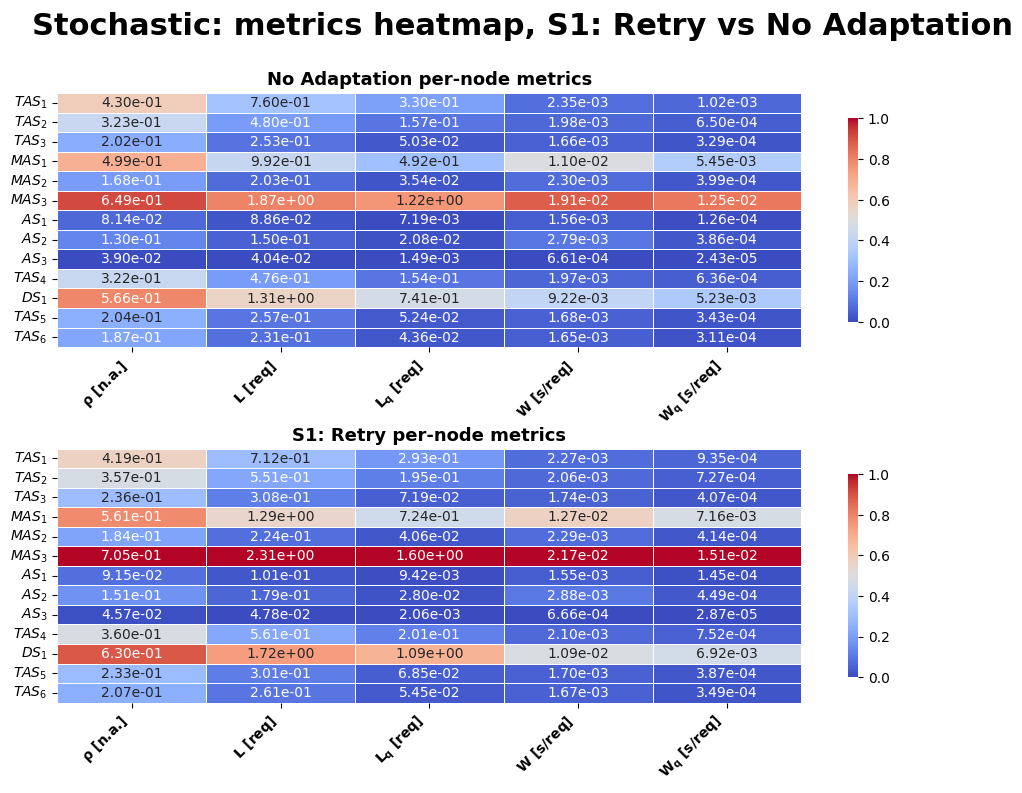

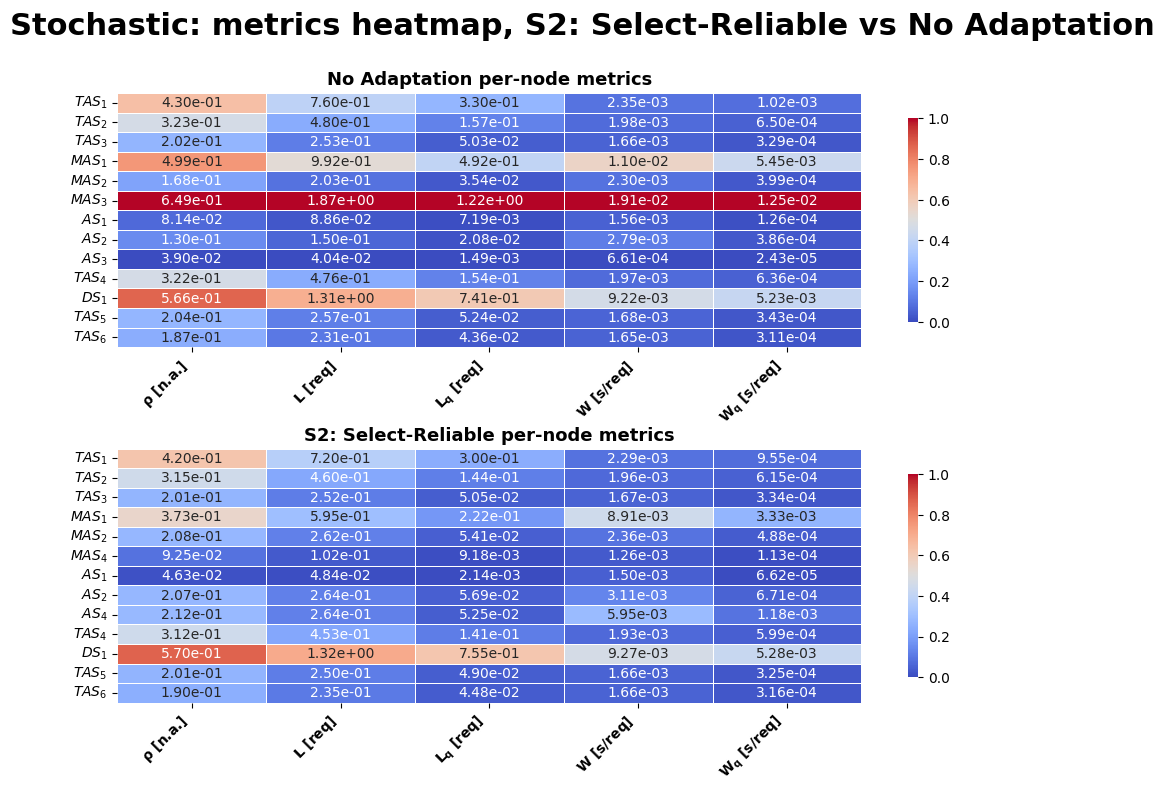

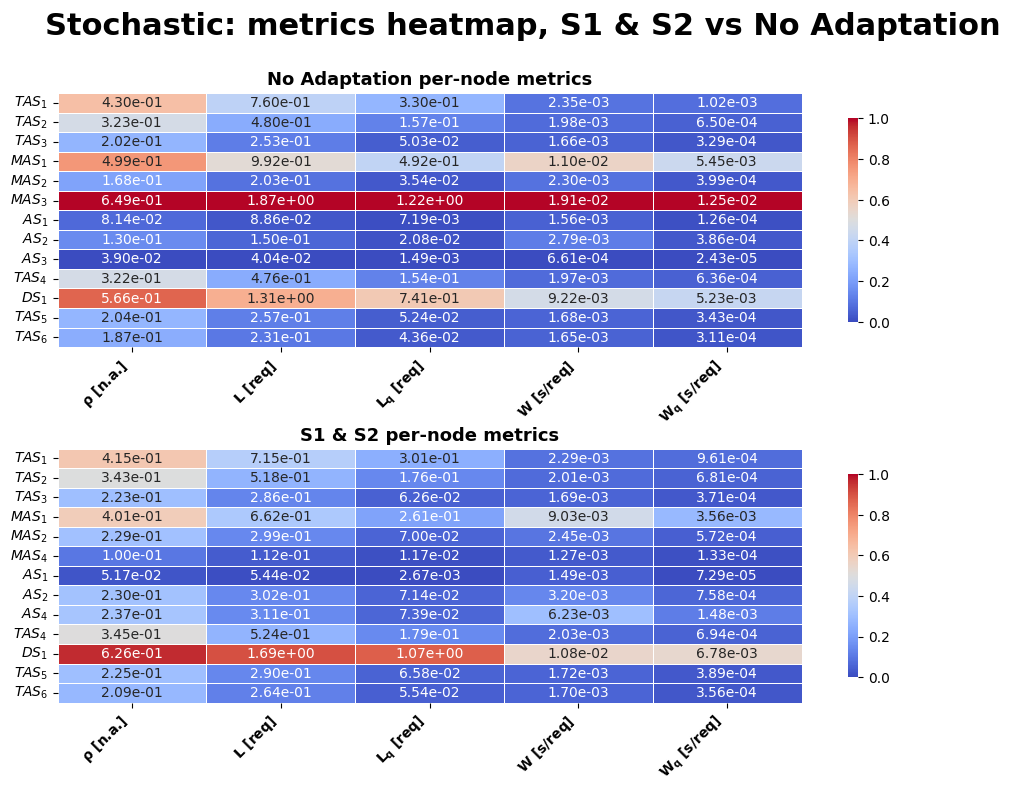

In [9]:
heat_metrics = ["rho", "L", "Lq", "W", "Wq"]
heat_labels = [
    r"$\mathbf{\rho}$ [n.a.]",
    r"$\mathbf{L}$ [req]",
    r"$\mathbf{L_q}$ [req]",
    r"$\mathbf{W}$ [s/req]",
    r"$\mathbf{W_q}$ [s/req]",
]

# plot_node_heatmap aligns rows positionally (iloc[i]); each panel's y-axis
for a in ["s1", "s2", "aggregate"]:
    plot_node_heatmap(
        ndss=[nodes["baseline"], nodes[a]],
        names=[DISPLAY["baseline"], DISPLAY[a]],
        metrics=heat_metrics,
        labels=heat_labels,
        title=f"Stochastic: metrics heatmap, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="heatmap_vs_baseline.png")

## 5b. Per-node delta heatmap (ratio vs baseline)

Same `(opti - dflt) / |dflt|` ratio convention as the analytic method. Values render as fractions: 35.82 reads as 3582 %.

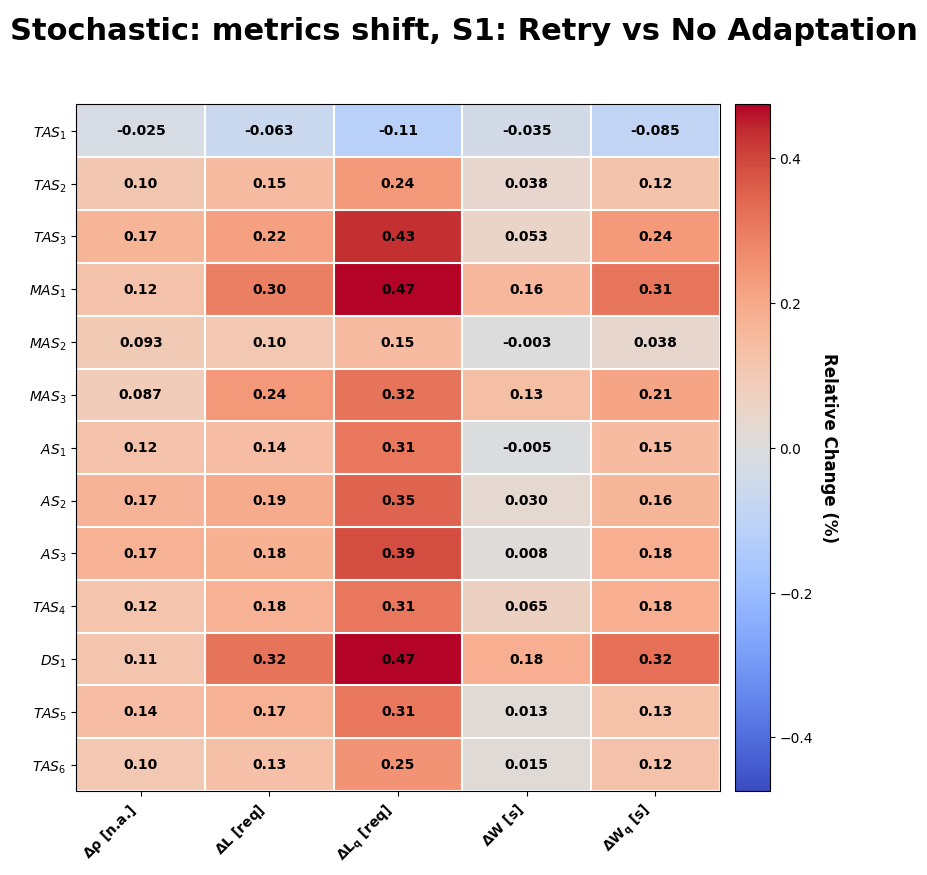

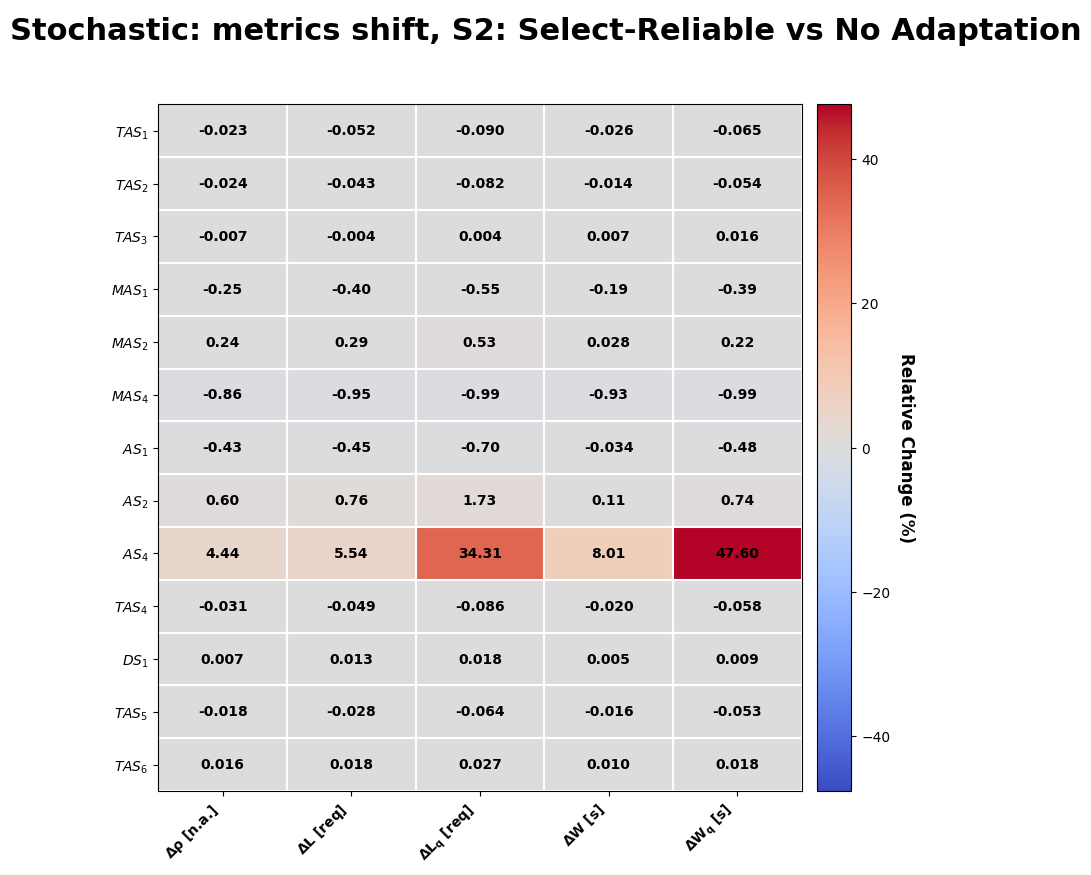

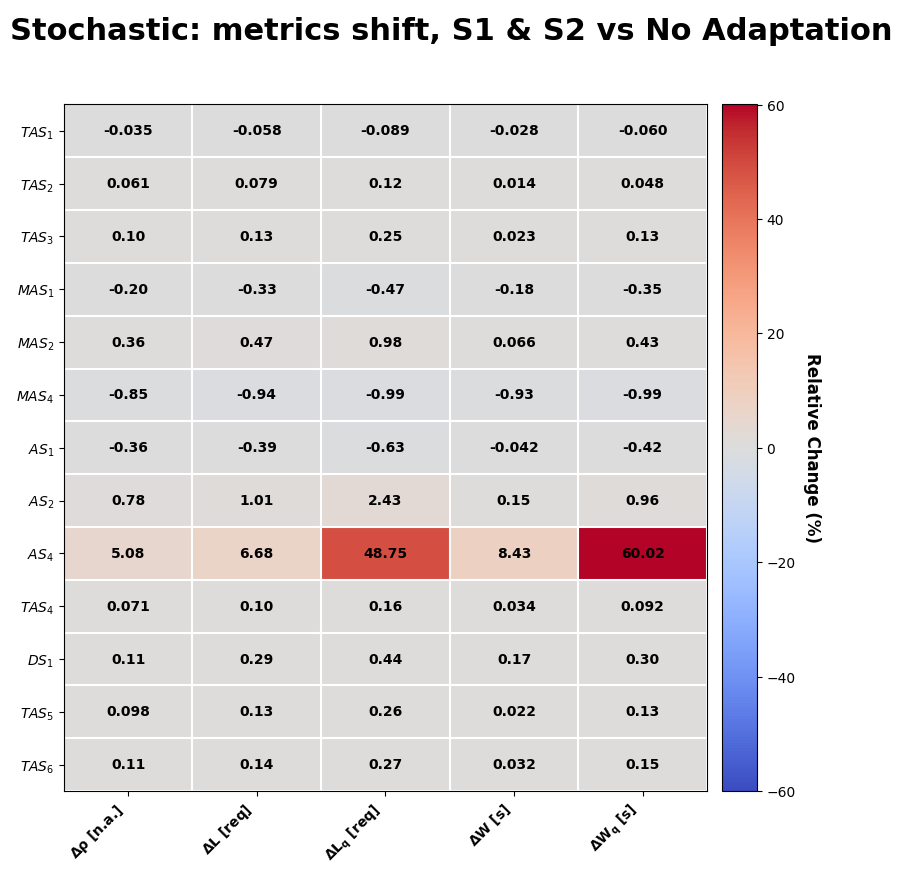

In [10]:
diff_metrics = ["rho", "L", "Lq", "W", "Wq"]
diff_labels = [
    r"$\mathbf{\Delta \rho}$ [n.a.]",
    r"$\mathbf{\Delta L}$ [req]",
    r"$\mathbf{\Delta L_q}$ [req]",
    r"$\mathbf{\Delta W}$ [s]",
    r"$\mathbf{\Delta W_q}$ [s]",
]
# Align by positional row index (baseline MAS_{3} vs s2 MAS_{4} at the same row);
# y-axis carries each adp's actual service keys.
bl_nodes = nodes["baseline"]
for a in ["s1", "s2", "aggregate"]:
    ac_nodes = nodes[a]
    rows = []
    for i in range(len(ac_nodes)):
        b_row = bl_nodes.iloc[i]
        c_row = ac_nodes.iloc[i]
        row = {"key": c_row["key"]}
        for m in diff_metrics:
            b, c = float(b_row[m]), float(c_row[m])
            row[m] = ((c - b) / abs(b)) if b else 0.0
        rows.append(row)
    deltas = pd.DataFrame(rows)
    plot_node_diffmap(
        deltas=deltas,
        nodes=deltas["key"].tolist(),
        metrics=diff_metrics,
        labels=diff_labels,
        title=f"Stochastic: metrics shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="nd_diffmap_vs_baseline.png")

## 6. Per-node confidence-interval bands (stochastic-only)

For each adaptation, plot the per-node mean with a 95 % CI error bar (half-width = `z * sigma / sqrt(reps)` using the replication-level sigma from the `_std` columns). The analytic closed-form baseline is overlaid as red `x` markers so the two methods can be eyeballed against each other: the analytic value should fall INSIDE the stochastic CI when the engine is calibrated correctly.

Both `rho` and `W` get their own panels per adaptation.

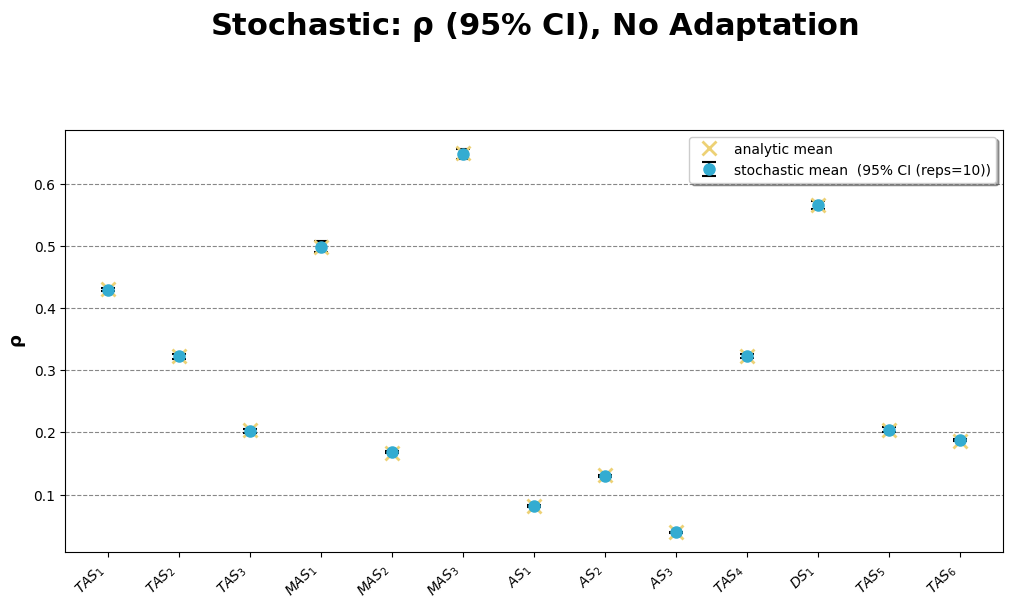

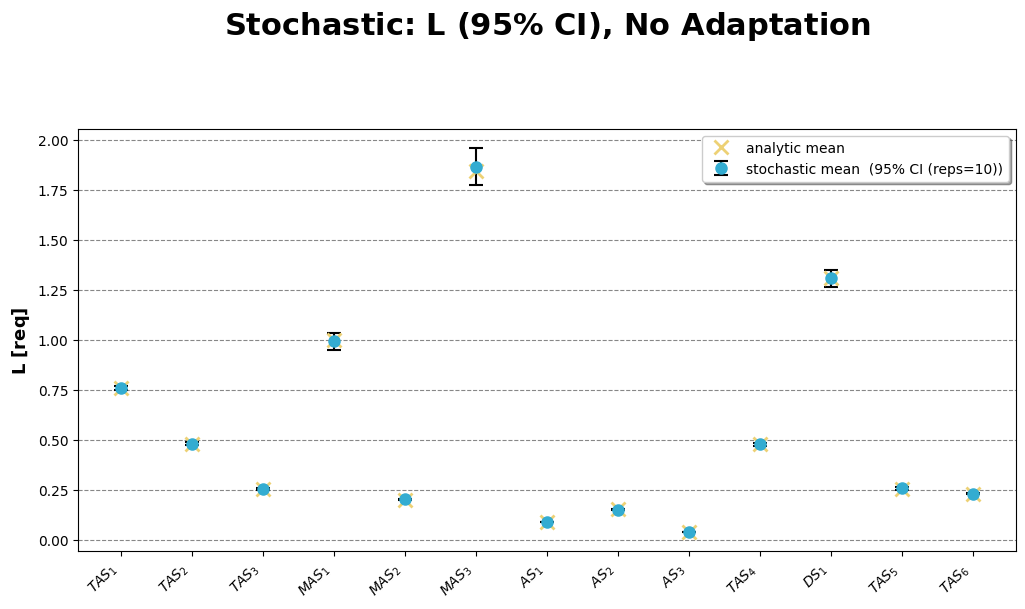

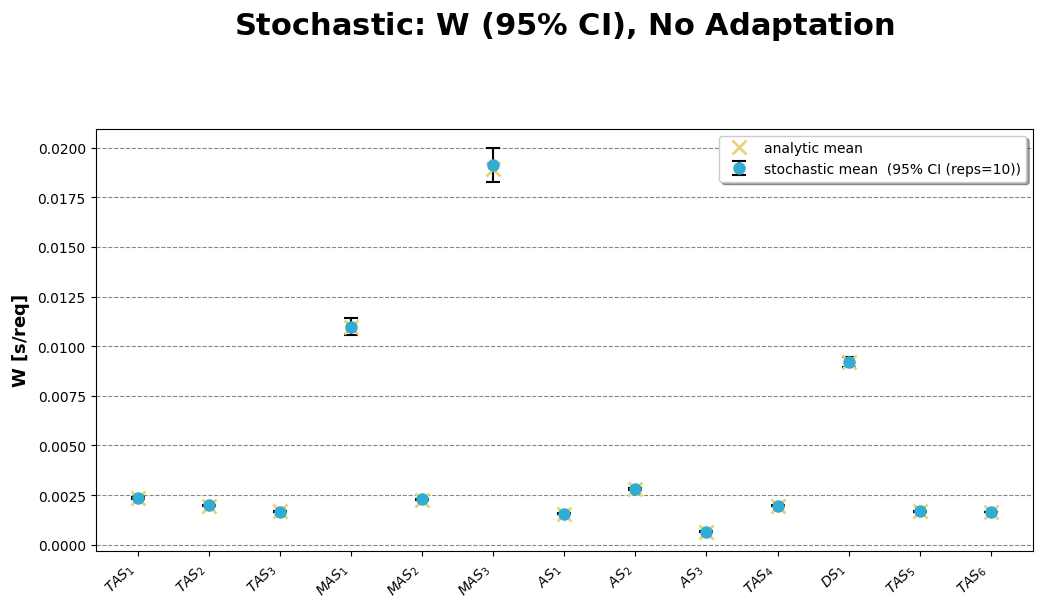

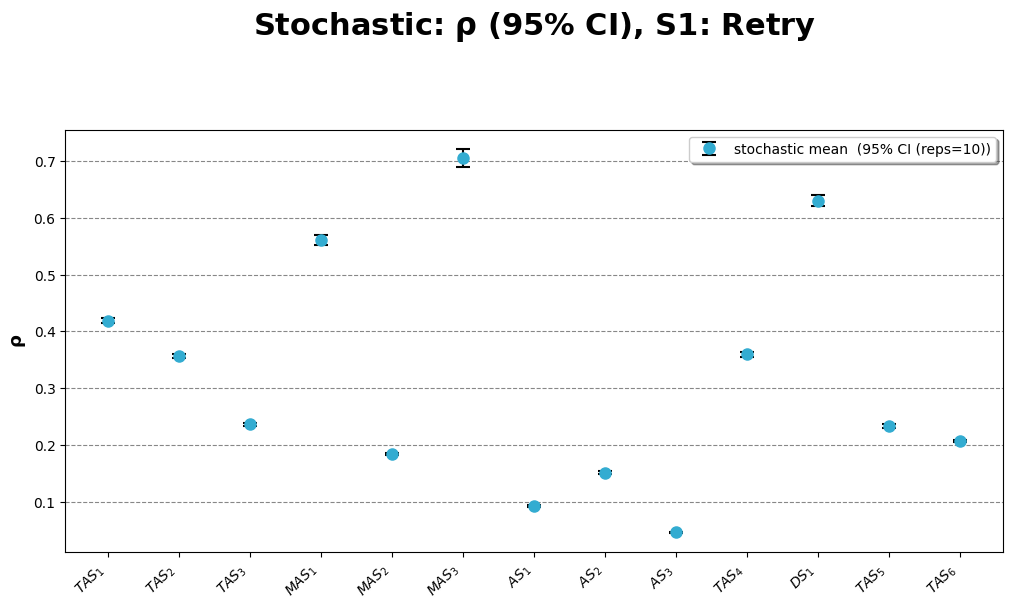

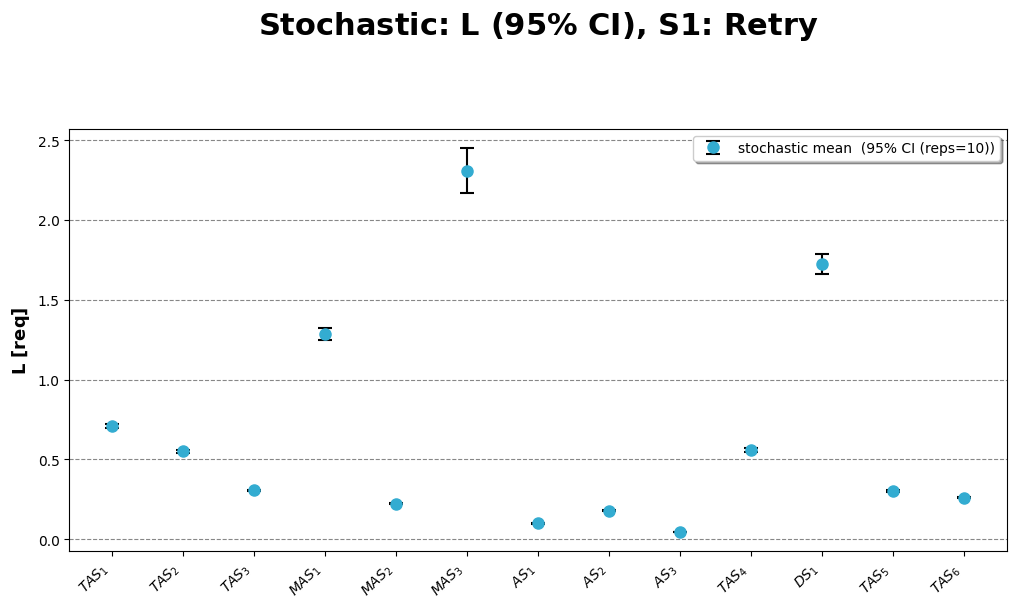

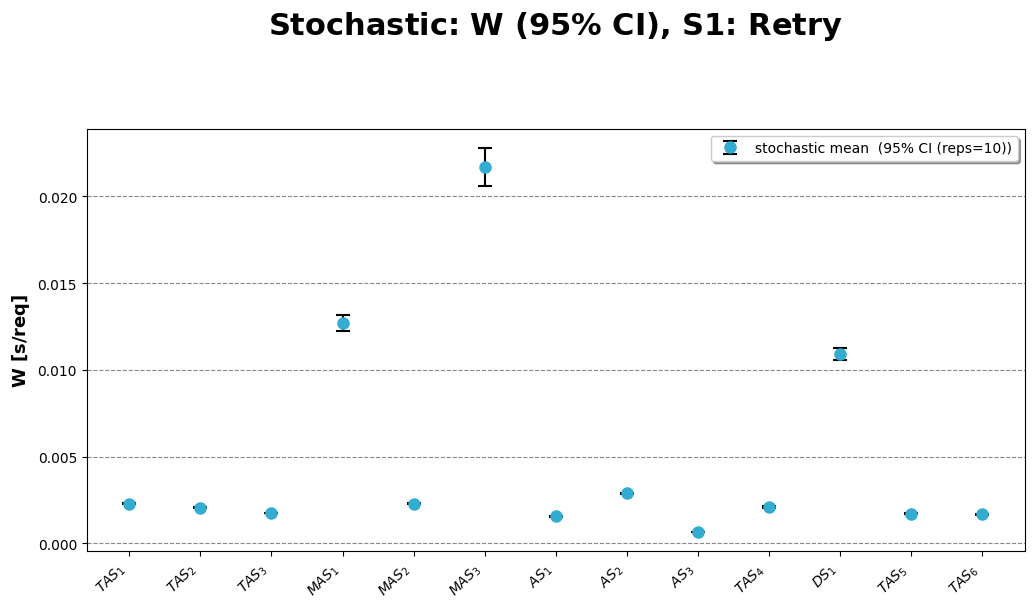

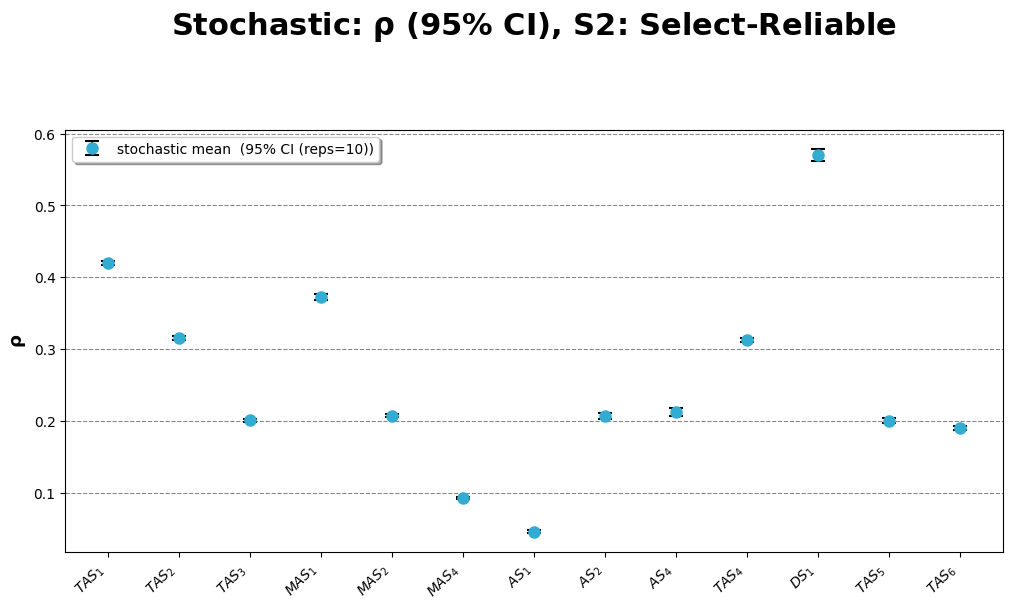

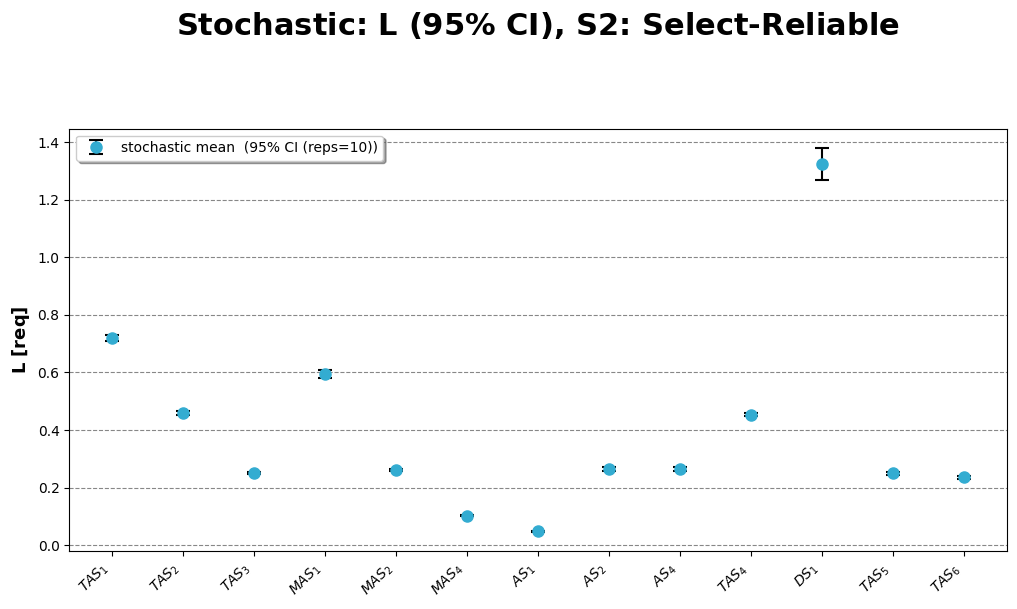

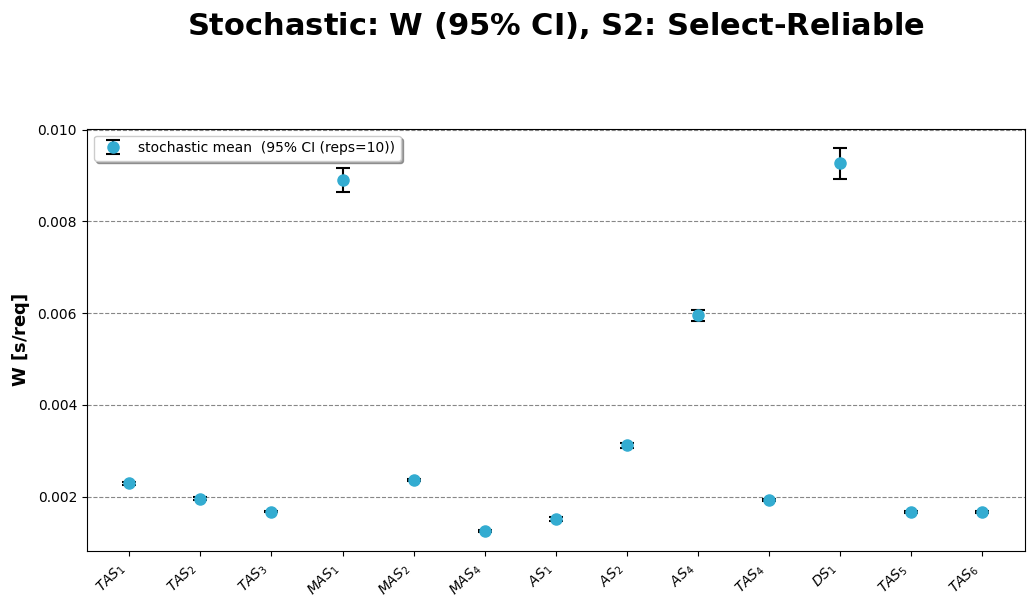

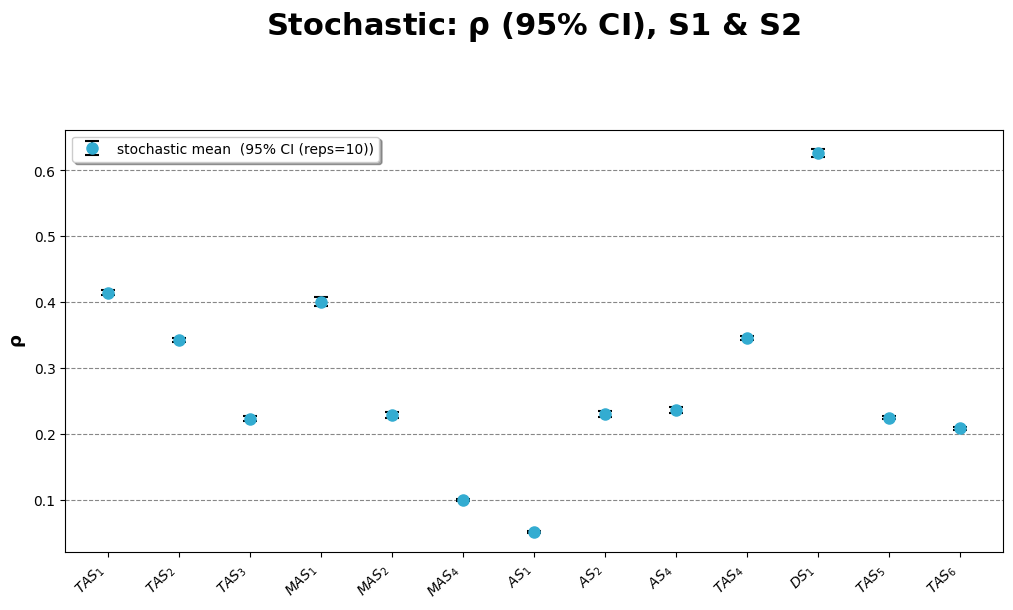

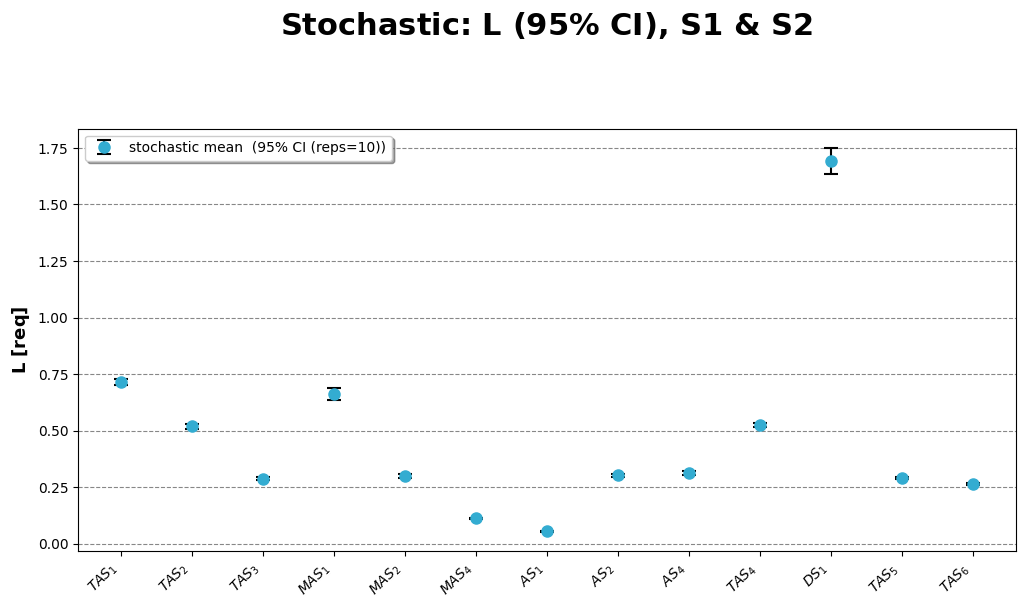

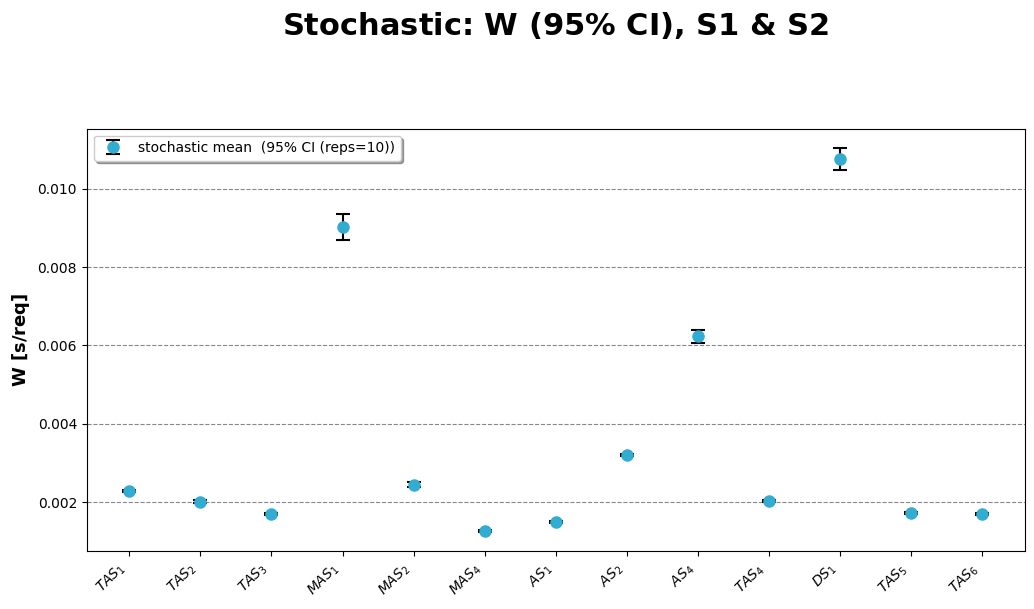

In [11]:
for a in ADAPTATIONS:
    plot_node_ci(
        nds=nodes[a],
        metric="rho",
        reference=analytic_baseline_nodes if a == "baseline" else None,
        reference_name="analytic",
        stochastic_name="stochastic",
        metric_label=r"$\mathbf{\rho}$",
        confidence=0.95,
        reps=mc["replications"],
        title=f"Stochastic: $\\mathbf{{\\rho}}$ (95% CI), {DISPLAY[a]}",
        file_path=str(IMG_ROOT / a),
        fname="nd_ci_rho.png")
    plot_node_ci(
        nds=nodes[a],
        metric="L",
        reference=analytic_baseline_nodes if a == "baseline" else None,
        reference_name="analytic",
        stochastic_name="stochastic",
        metric_label=r"$\mathbf{L}$ [req]",
        confidence=0.95,
        reps=mc["replications"],
        title=f"Stochastic: $\\mathbf{{L}}$ (95% CI), {DISPLAY[a]}",
        file_path=str(IMG_ROOT / a),
        fname="nd_ci_L.png")
    plot_node_ci(
        nds=nodes[a],
        metric="W",
        reference=analytic_baseline_nodes if a == "baseline" else None,
        reference_name="analytic",
        stochastic_name="stochastic",
        metric_label=r"$\mathbf{W}$ [s/req]",
        confidence=0.95,
        reps=mc["replications"],
        title=f"Stochastic: $\\mathbf{{W}}$ (95% CI), {DISPLAY[a]}",
        file_path=str(IMG_ROOT / a),
        fname="nd_ci_W.png")

## 7. Network-wide bars (all four adaptations)

Headline comparison of the four configurations on the metrics that drive R1 / R2. Log y-axis because metrics span several orders of magnitude.

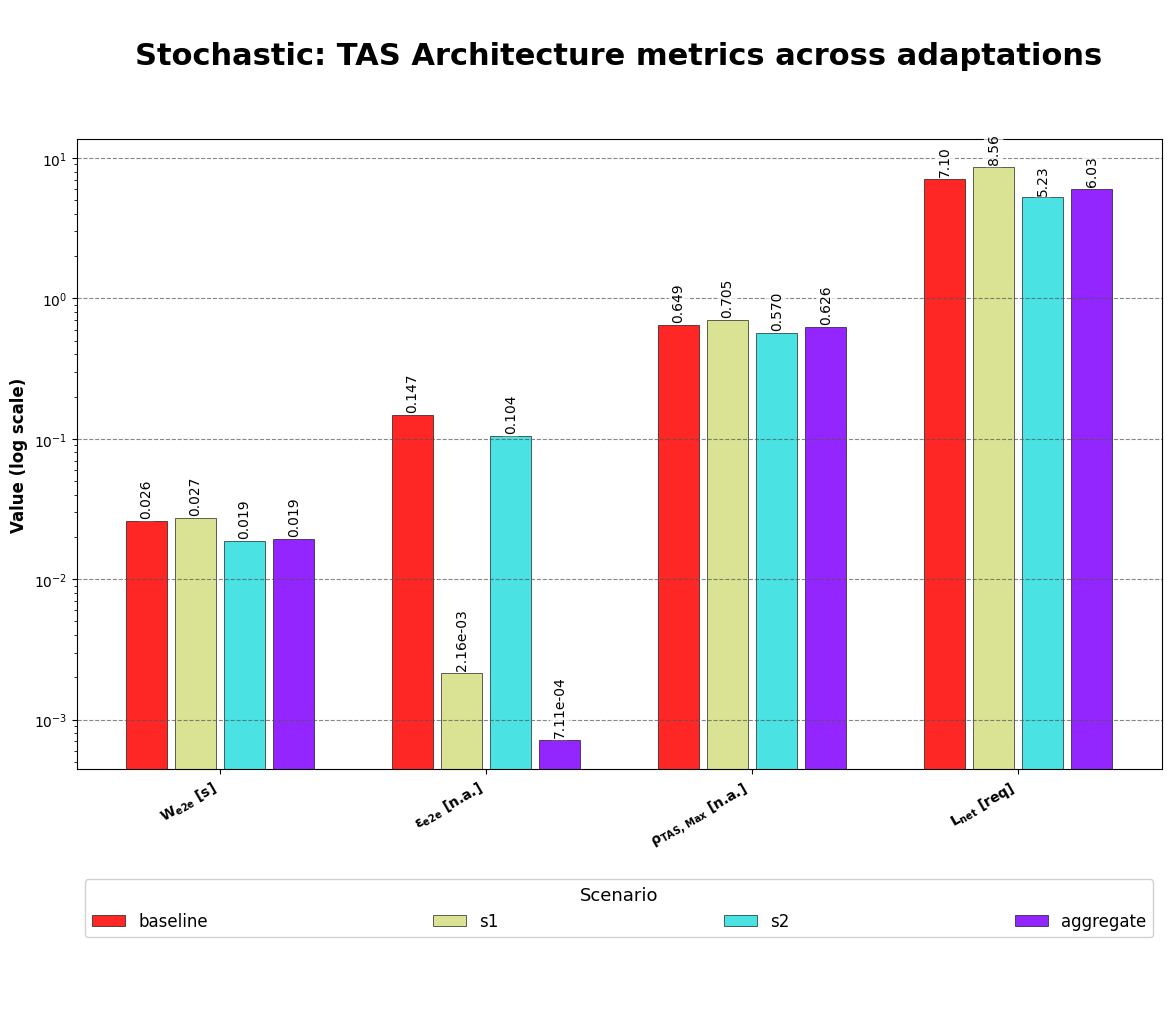

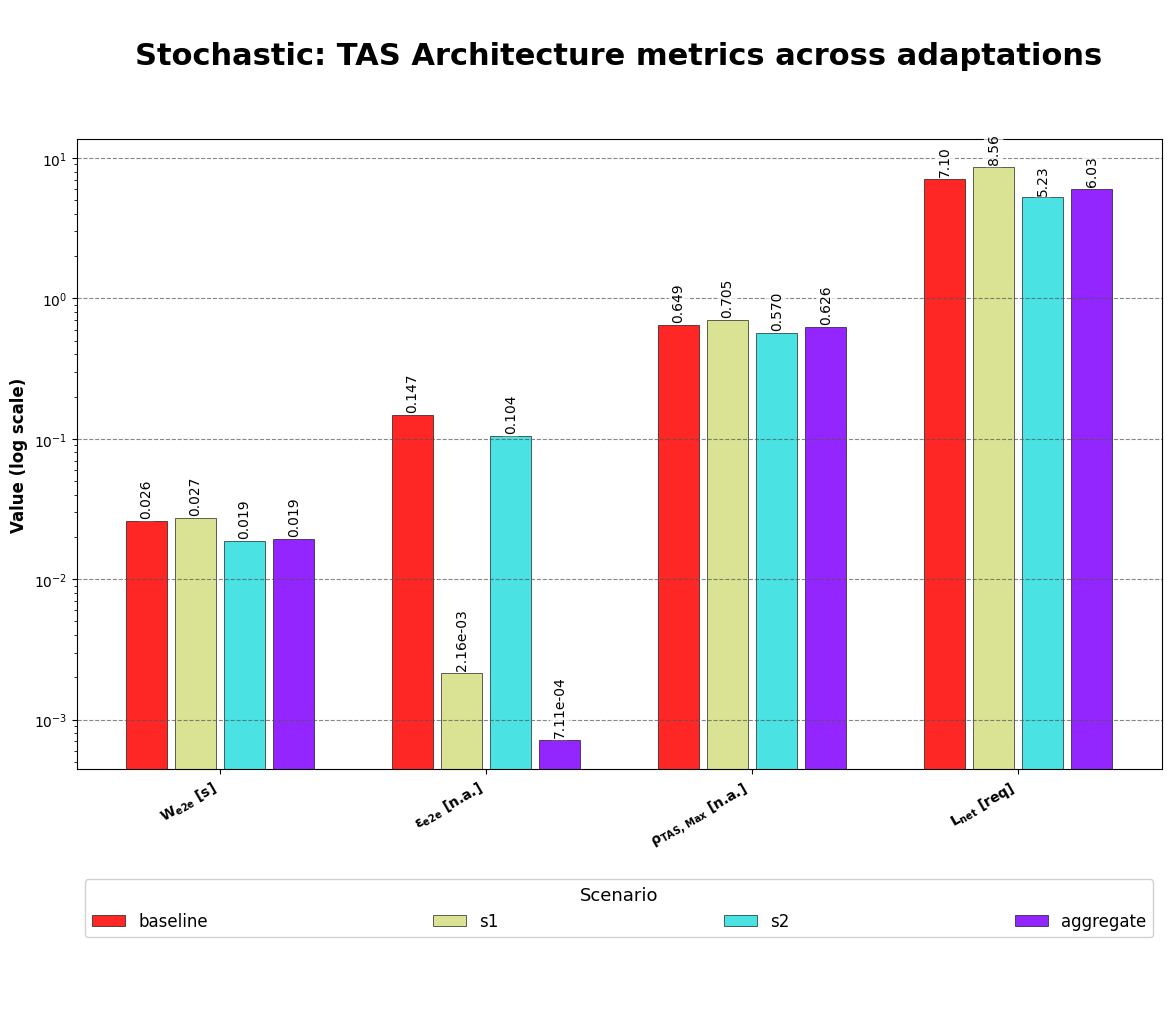

In [12]:
bar_metrics = ["W_e2e", "eps_e2e", "max_rho", "L_net"]
bar_labels = [
    r"$\mathbf{W_{e2e}}$ [s]",
    r"$\mathbf{\varepsilon_{e2e}}$ [n.a.]",
    r"$\mathbf{\rho_{TAS,\,Max}}$ [n.a.]",
    r"$\mathbf{L_{net}}$ [req]",
]

plot_arch_bars(
    nets=[nets[a] for a in ADAPTATIONS],
    names=ADAPTATIONS,
    metrics=bar_metrics,
    labels=bar_labels,
    title="Stochastic: TAS Architecture metrics across adaptations",
    file_path=str(IMG_ROOT / "aggregate"),
    fname="net_bars_all.png")

## 8. Network-wide delta (% change vs baseline)

Semantic colouring: negative delta = improvement (green), positive = degradation (red).

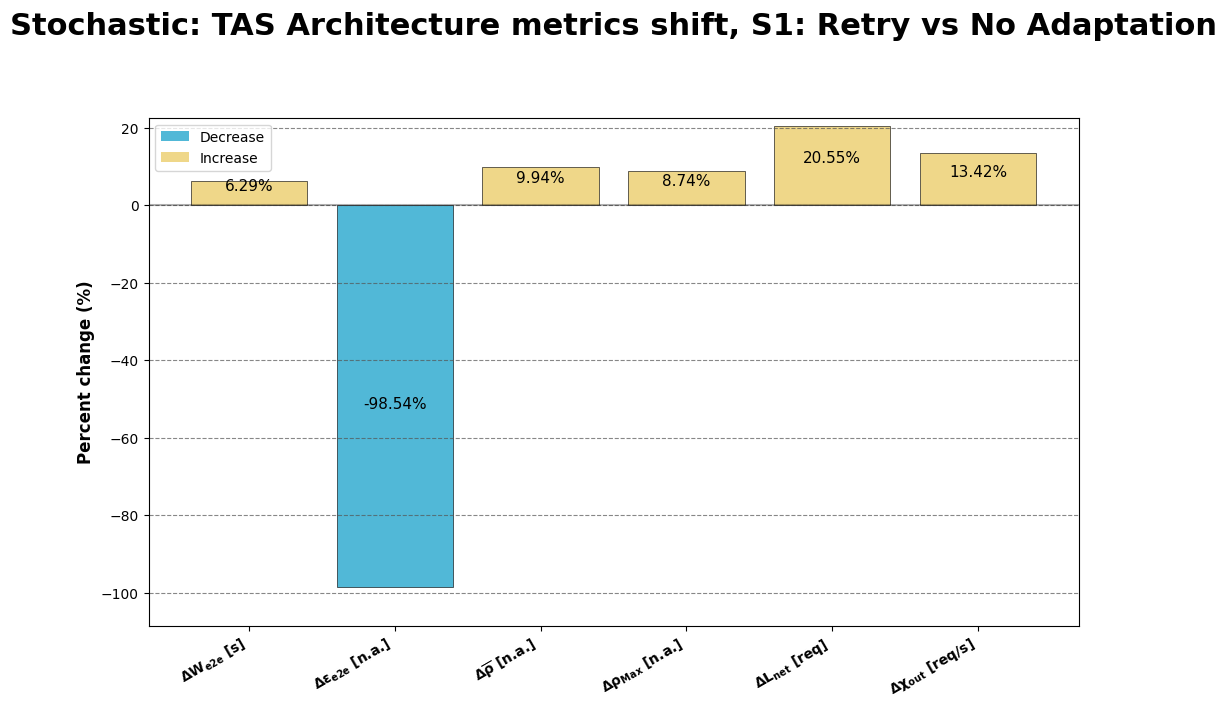

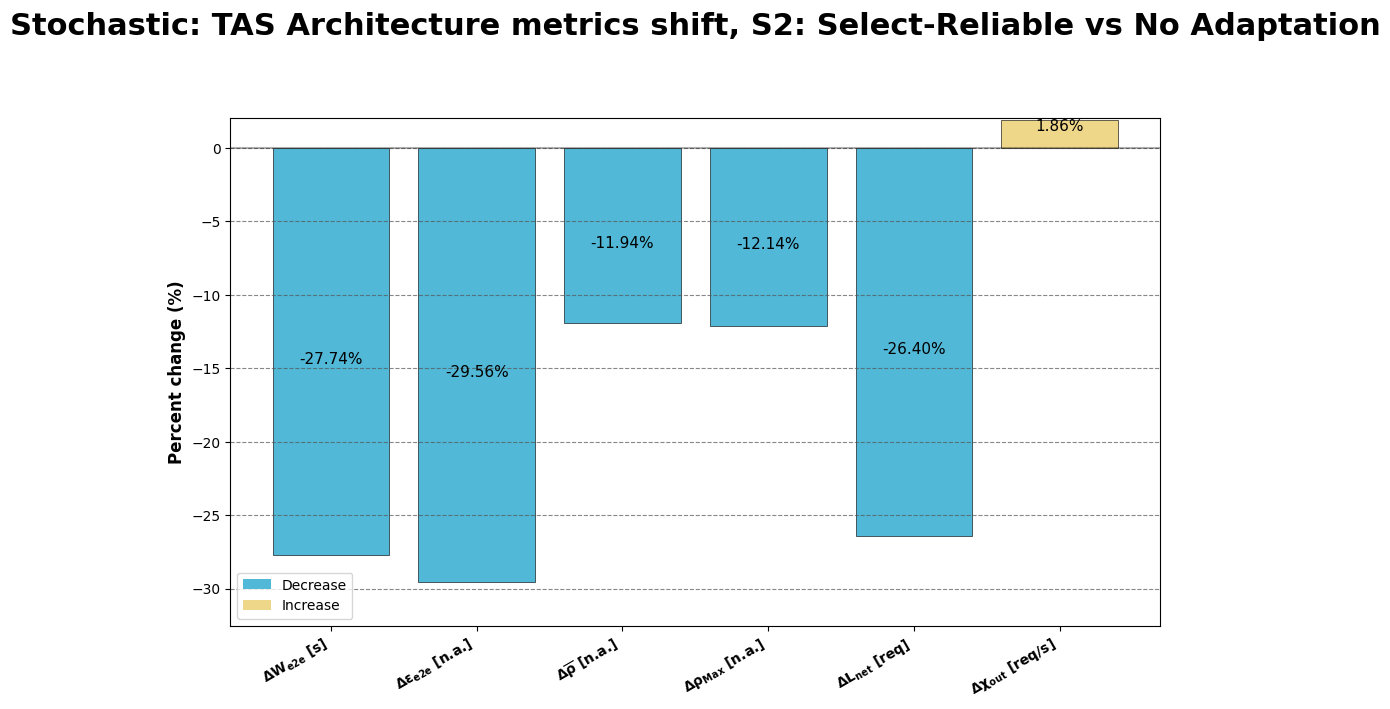

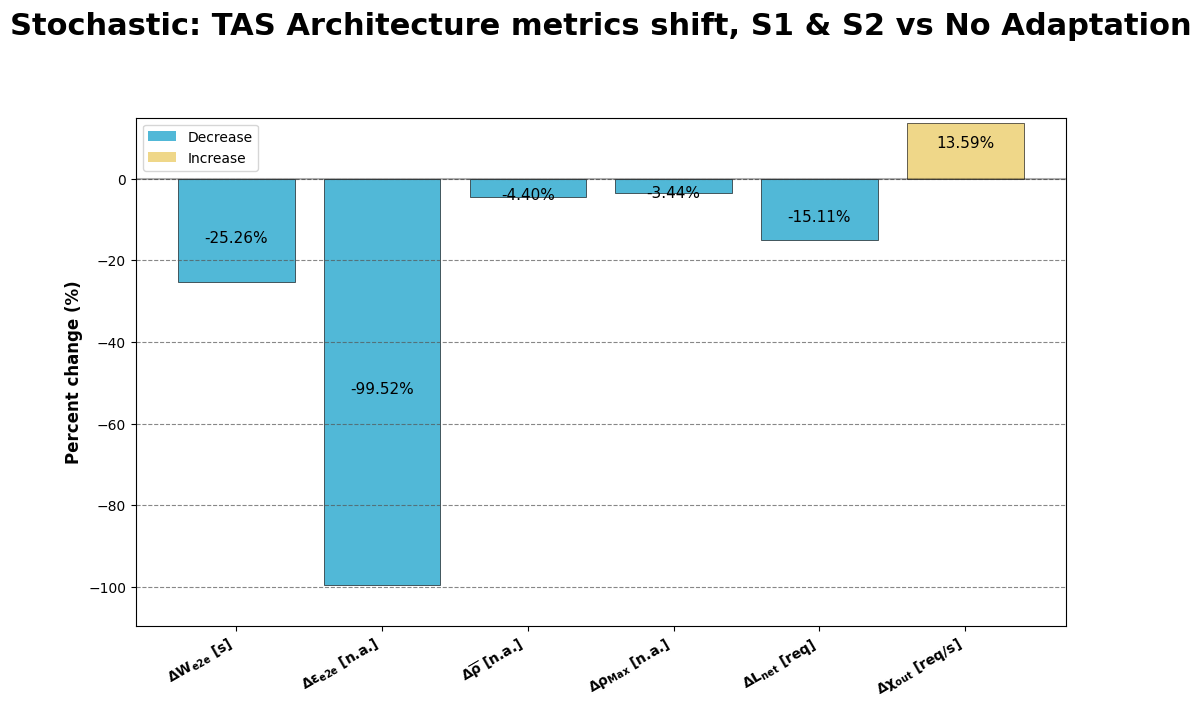

In [13]:
delta_metrics = [
    "W_e2e", "eps_e2e",
    "avg_rho", "max_rho",
    "L_net", "chi_out",
]
delta_labels = [
    r"$\mathbf{\Delta W_{e2e}}$ [s]",
    r"$\mathbf{\Delta \varepsilon_{e2e}}$ [n.a.]",
    r"$\mathbf{\Delta \overline{\rho}}$ [n.a.]",
    r"$\mathbf{\Delta \rho_{Max}}$ [n.a.]",
    r"$\mathbf{\Delta L_{net}}$ [req]",
    r"$\mathbf{\Delta \chi_{out}}$ [req/s]",
]
bl = nets["baseline"].iloc[0]
for a in ["s1", "s2", "aggregate"]:
    ac = nets[a].iloc[0]
    row = {
        m: (ac[m] - bl[m]) / bl[m] if bl[m] else 0.0
        for m in delta_metrics
    }
    plot_arch_delta(
        deltas=pd.DataFrame([row]),
        metrics=delta_metrics,
        labels=delta_labels,
        title=f"Stochastic: TAS Architecture metrics shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="net_delta_vs_baseline.png")

## 9. R1 / R2 verdict table

Thresholds come from [`data/reference/baseline.json`](data/reference/baseline.json):

- **R1** Availability: `eps_e2e <= 1.00 %` (Weyns 2015 SEAMS)
- **R2** Performance: `W_e2e <= 26 ms` (Camara 2023)

End-to-end values come from the **loss-network** flow: failures are routing leaks the DES absorbs at the `FAIL_{1}` sink, so availability is measured directly from flow:

- `eps_e2e = lambda_FAIL / lambda_z` (fraction of jobs the DES routes to the FAIL sink)
- `chi_out = lambda_z - lambda_FAIL` (successful-completion rate)
- `W_e2e = L_net / chi_out` (per-request end-to-end response time)

The table carries the verdict per adaptation alongside the single top contributor node from `data/results/stochastic/<adp>/requirements.json`.

In [14]:
req_rows = []
for a in ADAPTATIONS:
    r = reqs[a]
    r1_top = r["R1"]["contributions"][0] if r["R1"].get("contributions") else {}
    r2_top = r["R2"]["contributions"][0] if r["R2"].get("contributions") else {}
    req_rows.append({
        "adaptation": a,
        "eps_e2e [%]": round(r["R1"]["value"] * 100, 3),
        "R1 (≤ 1%)": "PASS" if r["R1"]["pass"] else "FAIL",
        "R1 top contributor": f"{r1_top.get('node','-')} ({r1_top.get('contribution',0)*100:.2f}%)" if r1_top else "-",
        "W_e2e [ms]": round(r["R2"]["value"] * 1000, 3),
        "R2 (≤ 26 ms)": "PASS" if r["R2"]["pass"] else "FAIL",
        "R2 top contributor": f"{r2_top.get('node','-')} ({r2_top.get('share',0)*100:.1f}%)" if r2_top else "-",
    })
pd.DataFrame(req_rows).set_index("adaptation")

,eps_e2e [%],R1 (≤ 1%),R1 top contributor,W_e2e [ms],R2 (≤ 26 ms),R2 top contributor
adaptation,,,,,,
baseline,14.748,FAIL,TAS_{4} (9.20%),25.799,PASS,MAS_{3} (26.3%)
s1,0.216,PASS,TAS_{4} (0.14%),27.421,FAIL,MAS_{3} (27.0%)
s2,10.388,FAIL,TAS_{4} (6.89%),18.642,PASS,DS_{1} (25.3%)
aggregate,0.071,PASS,TAS_{4} (0.06%),19.281,PASS,DS_{1} (28.1%)


## Summary

At the locked envelope (`lambda_z = 323 req/s`, E-QS canonical inflection), the SimPy DES estimates of per-node W, L, rho fall inside the 95 % CI of the analytic closed-form solution (section 6), corroborating the analytic per-node measurements. End-to-end values follow the same **loss-network** flow model as the analytic notebook: the DES leaks give-ups to the `FAIL_{1}` sink, so `eps_e2e = lambda_FAIL/lambda_z` is measured directly from flow.

- **R1 (Availability):** the DES verdict tracks the analytic flow result within replication noise. Baseline and S2 fail (14.7% / 10.4%, catalogue-bound); S1 and the aggregate pass (retry recovers, residual ~ f^k, giving 0.22% / 0.07%).
- **R2 (Performance):** baseline, S2, and the aggregate pass; S1 fails (27.4 ms) because retry re-dispatch overloads the pools. DES `W_e2e` matches the analytic within ~3%.

Cross-method agreement (DES vs analytic, the section 6 CI overlay) is the empirical justification for the loss-network verdict chain. The per-requirement top-contributor lists in section 9 give the node-level evidence per scenario (`TAS_{4}` dominates R1 as the medical give-up handler; `MAS_{3}` / `DS_{1}` dominate R2).

**Next method in the pipeline**: `03-dimensional.ipynb` (PyDASA Pi-groups + dimensional R1 / R2 bounds via `sigma_R2`, `eta_R1`).